In [4]:
# CELLULE 2.1 : Import et connexion

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import pyodbc
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
from matplotlib.ticker import FuncFormatter, MaxNLocator

print("="*70)
print("OBJECTIF 2 : ADVANCED CUSTOMER SEGMENTATION")
print("="*70)

# Connexion SQL Server
SERVER = 'LAPTOP-MPK2261L'
DATABASE = 'dw_pi'

try:
    conn_str = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes'
    conn = pyodbc.connect(conn_str, timeout=30)
    print("✅ Connecté avec ODBC Driver 17")
except:
    try:
        conn_str = f'DRIVER={{SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes'
        conn = pyodbc.connect(conn_str, timeout=30)
        print("✅ Connecté avec SQL Server")
    except Exception as e:
        print(f"❌ Erreur: {e}")
        conn = None

if conn is None:
    print("❌ Impossible de se connecter")
    exit()

OBJECTIF 2 : ADVANCED CUSTOMER SEGMENTATION
✅ Connecté avec ODBC Driver 17


In [5]:
# CELLULE 2.2 : Extraction des données clients (CORRIGÉE)

print("\n📊 Extraction des données clients...")

# Vérifier d'abord la structure des tables
cursor = conn.cursor()

# Afficher les colonnes de fact_sale
print("\n🔍 Structure de fact_sale :")
cursor.execute("""
    SELECT COLUMN_NAME, DATA_TYPE 
    FROM INFORMATION_SCHEMA.COLUMNS 
    WHERE TABLE_NAME = 'fact_sale'
""")
for row in cursor.fetchall():
    print(f"   - {row[0]} ({row[1]})")

# Extraction des clients B2B et B2C avec jointure correcte
query = """
SELECT 
    s.fk_clientB2B as client_id,
    'B2B' as client_type,
    s.fk_date,
    s.quantity,
    s.total_price,
    s.discount
FROM fact_sale s
WHERE s.fk_clientB2B IS NOT NULL

UNION ALL

SELECT 
    s.fk_clientB2C as client_id,
    'B2C' as client_type,
    s.fk_date,
    s.quantity,
    s.total_price,
    s.discount
FROM fact_sale s
WHERE s.fk_clientB2C IS NOT NULL
"""

df_clients = pd.read_sql(query, conn)

# Nettoyage et conversion des dates
# Récupérer les dates depuis dim_date
query_dates = """
SELECT 
    d.pk_id_date,
    d.full_date
FROM dim_date d
"""

df_dates = pd.read_sql(query_dates, conn)

# Joindre les dates
df_clients = df_clients.merge(df_dates, left_on='fk_date', right_on='pk_id_date', how='left')

# Utiliser full_date comme date
df_clients['fk_date'] = pd.to_datetime(df_clients['full_date'])
df_clients['quantity'] = pd.to_numeric(df_clients['quantity'], errors='coerce').fillna(0).astype(int)
df_clients['total_price'] = pd.to_numeric(df_clients['total_price'], errors='coerce').fillna(0)
df_clients['discount'] = pd.to_numeric(df_clients['discount'], errors='coerce').fillna(0)

# Supprimer les lignes avec des dates invalides
df_clients = df_clients[df_clients['fk_date'] > '2000-01-01']

print(f"✅ {len(df_clients):,} transactions extraites")
print(f"📅 Période : {df_clients['fk_date'].min().date()} → {df_clients['fk_date'].max().date()}")
print(f"👥 Clients uniques : {df_clients['client_id'].nunique()}")
print(f"📊 Types : B2B = {df_clients[df_clients['client_type']=='B2B']['client_id'].nunique()} | B2C = {df_clients[df_clients['client_type']=='B2C']['client_id'].nunique()}")


📊 Extraction des données clients...

🔍 Structure de fact_sale :
   - pk_id_sale (int)
   - fk_date (int)
   - fk_place (int)
   - fk_product (int)
   - fk_claim (int)
   - fk_order (int)
   - fk_clientB2B (int)
   - fk_clientB2C (int)
   - fk_channel (int)
   - fk_invoice (int)
   - quantity (int)
   - ugs (nvarchar)
   - tax_status (nvarchar)
   - unit_price (decimal)
   - discount (decimal)
   - total_price (decimal)
✅ 120 transactions extraites
📅 Période : 2023-12-30 → 2026-01-02
👥 Clients uniques : 36
📊 Types : B2B = 4 | B2C = 34


In [6]:
# CELLULE 2.3 : Calcul RFM

print("\n" + "="*70)
print("📊 CALCUL RFM (Recency, Frequency, Monetary)")
print("="*70)

# Date de référence
reference_date = df_clients['fk_date'].max()

# Agrégation par client
rfm = df_clients.groupby(['client_id', 'client_type']).agg({
    'fk_date': lambda x: (reference_date - x.max()).days,
    'quantity': 'count',
    'total_price': 'sum',
    'discount': 'mean'
}).reset_index()

rfm.columns = ['client_id', 'client_type', 'recency', 'frequency', 'monetary', 'avg_discount']

# Conversion en entiers
rfm['recency'] = rfm['recency'].astype(int)
rfm['frequency'] = rfm['frequency'].astype(int)
rfm['monetary'] = rfm['monetary'].round(2)
rfm['avg_discount'] = rfm['avg_discount'].round(2)

# Supprimer les clients sans transactions valides
rfm = rfm[rfm['frequency'] > 0]

print(f"✅ RFM calculé pour {len(rfm)} clients")
print(f"\n📊 STATISTIQUES RFM :")
print(f"   Récence - Min: {rfm['recency'].min()} | Max: {rfm['recency'].max()} | Moy: {rfm['recency'].mean():.1f} jours")
print(f"   Fréquence - Min: {rfm['frequency'].min()} | Max: {rfm['frequency'].max()} | Moy: {rfm['frequency'].mean():.1f} achats")
print(f"   Montant - Min: {rfm['monetary'].min():.0f} | Max: {rfm['monetary'].max():.0f} | Moy: {rfm['monetary'].mean():.0f} DT")

# Afficher les clients
print("\n📋 LISTE DES CLIENTS :")
print(rfm.to_string(index=False))


📊 CALCUL RFM (Recency, Frequency, Monetary)
✅ RFM calculé pour 38 clients

📊 STATISTIQUES RFM :
   Récence - Min: 0 | Max: 734 | Moy: 174.7 jours
   Fréquence - Min: 1 | Max: 34 | Moy: 3.2 achats
   Montant - Min: 25 | Max: 2980 | Moy: 296 DT

📋 LISTE DES CLIENTS :
 client_id client_type  recency  frequency  monetary  avg_discount
         1         B2B        0         34   2979.91           0.0
         1         B2C        0          1    100.00           0.0
         2         B2B        4         16   1605.60           0.0
         3         B2B        4          6    674.00           0.0
         3         B2C        4          3    459.00           0.0
         4         B2B       20          4    371.00           0.0
        13         B2C        6          1     30.00           0.0
        18         B2C        7          2    199.80           0.0
        34         B2C        9          1    150.00           0.0
        42         B2C       16          2    212.00           


📊 DATA PREPARATION & FEATURE ENGINEERING

1. DATA CLEANING
----------------------------------------
Valeurs manquantes avant traitement :
   recency : 0
   frequency : 0
   monetary : 0
✅ Après suppression des NaN : 38 clients (vs 38 avant)
✅ Outliers détectés et traités (clipping) : 0 valeurs
   recency: 0 outlier(s)
   frequency: 0 outlier(s)
   monetary: 0 outlier(s)
✅ Encodage de client_type : B2B → 1, B2C → 0

2. FEATURE ENGINEERING
----------------------------------------
✅ Nouvelles features créées : rfm_score, log_monetary, freq_per_recency

3. FEATURE SELECTION (Filter method - corrélation)
----------------------------------------
Corrélation des features avec 'monetary' :
   monetary: 1.0000
   log_monetary: 0.9219
   frequency: 0.9138
   rfm_score: 0.7070
   client_type_encoded: 0.6923
   freq_per_recency: 0.5362
   recency: -0.4144
   avg_discount: nan

✅ Features retenues par corrélation (avec monetary) : ['log_monetary', 'frequency', 'rfm_score', 'client_type_encoded', '

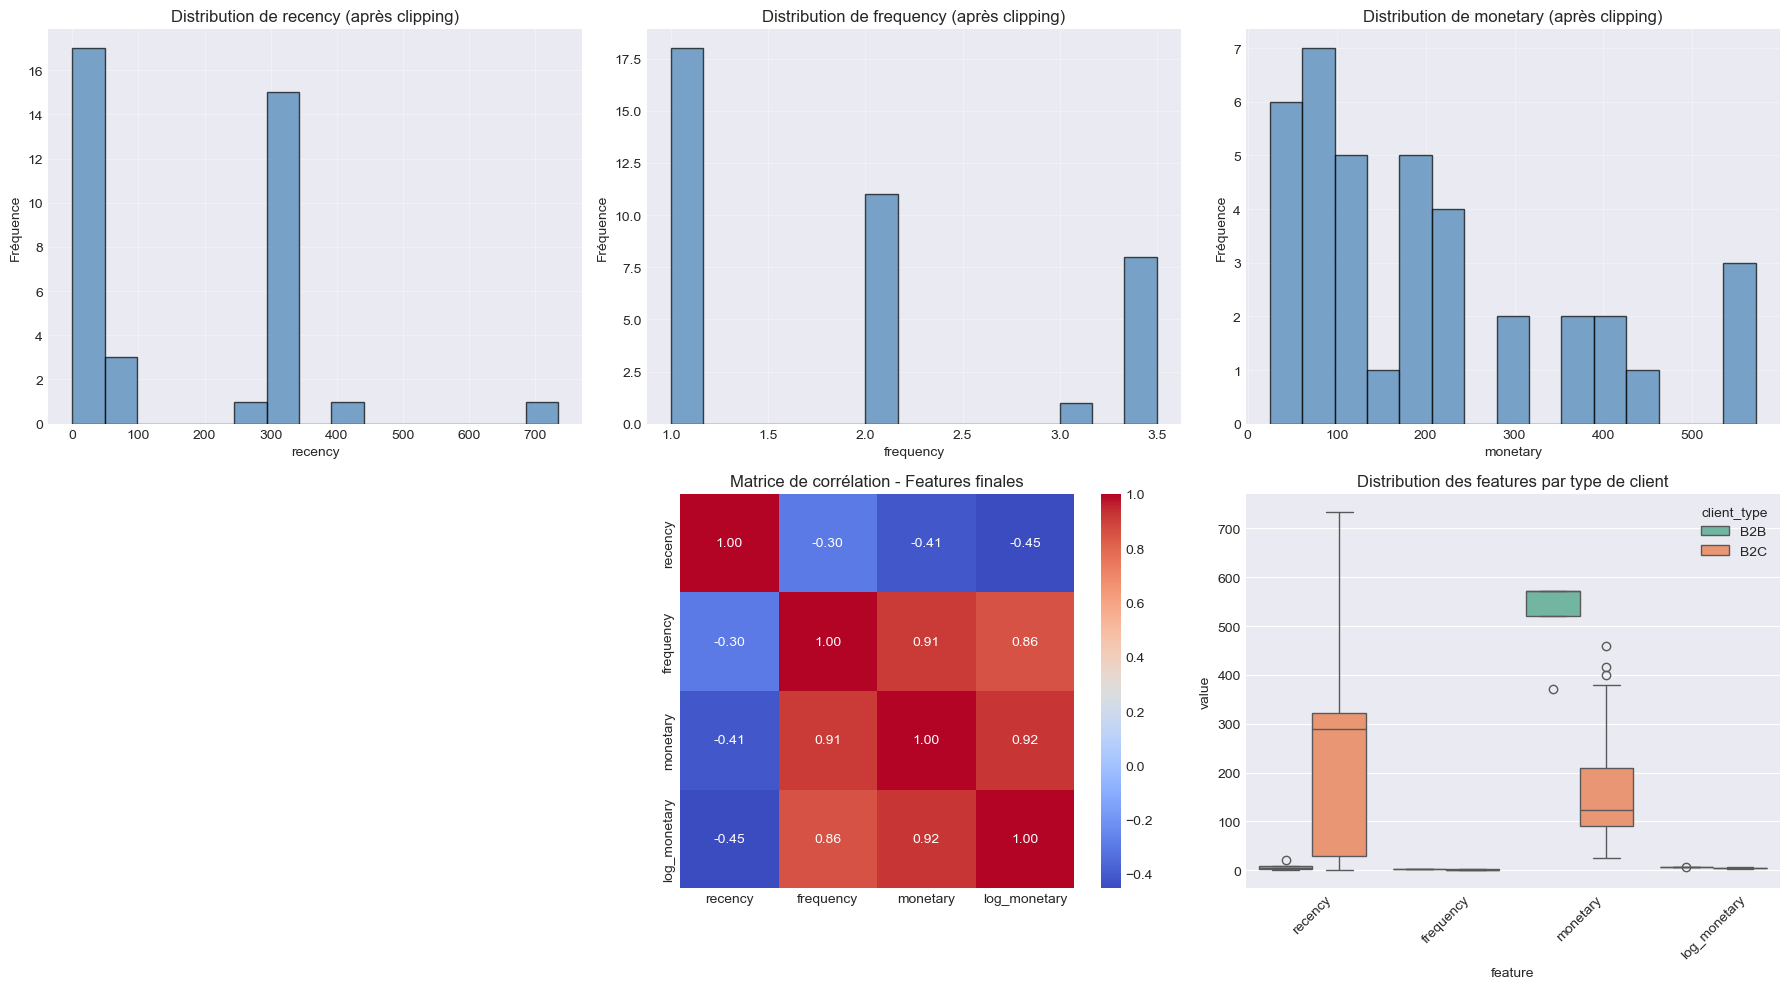

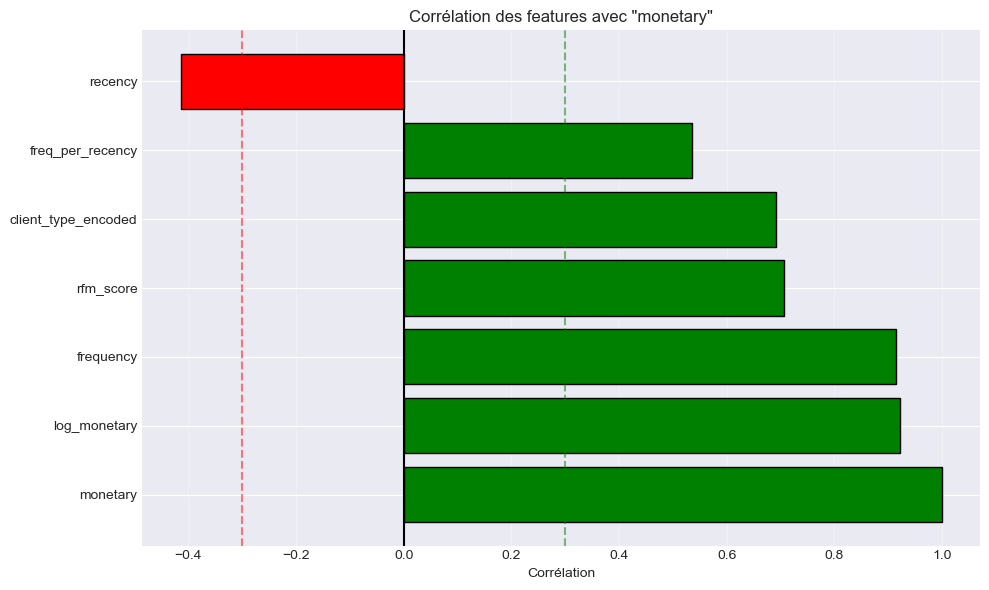


✅ Data Preparation & Feature Engineering terminé


In [8]:
# CELLULE 2.3bis : DATA PREPARATION & FEATURE ENGINEERING (AVEC VISUALISATIONS)

print("\n" + "="*70)
print("📊 DATA PREPARATION & FEATURE ENGINEERING")
print("="*70)

# ============================================
# 1. DATA CLEANING
# ============================================

print("\n1. DATA CLEANING")
print("-"*40)

# Vérifier que rfm existe
if 'rfm' not in locals():
    print("❌ Le DataFrame 'rfm' n'existe pas. Exécutez d'abord la cellule de calcul RFM.")
    exit()

# 1.1 Valeurs manquantes
print(f"Valeurs manquantes avant traitement :")
print(f"   recency : {rfm['recency'].isnull().sum()}")
print(f"   frequency : {rfm['frequency'].isnull().sum()}")
print(f"   monetary : {rfm['monetary'].isnull().sum()}")

# Supprimer les lignes avec des valeurs manquantes (peu probable ici)
rfm_clean = rfm.dropna().copy()
print(f"✅ Après suppression des NaN : {len(rfm_clean)} clients (vs {len(rfm)} avant)")

# 1.2 Détection et traitement des outliers (méthode IQR)
outliers_count = 0
outliers_info = {}
for col in ['recency', 'frequency', 'monetary']:
    Q1 = rfm_clean[col].quantile(0.25)
    Q3 = rfm_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = (rfm_clean[col] < lower) | (rfm_clean[col] > upper)
    outliers_info[col] = outliers.sum()
    outliers_count += outliers.sum()
    # On plafonne (clipping) plutôt que supprimer
    rfm_clean[col] = rfm_clean[col].clip(lower=lower, upper=upper)
print(f"✅ Outliers détectés et traités (clipping) : {outliers_count} valeurs")
for col, cnt in outliers_info.items():
    print(f"   {col}: {cnt} outlier(s)")

# 1.3 Encodage (pour les variables catégorielles)
# client_type est une variable catégorielle, on l'encode en numérique
rfm_clean['client_type_encoded'] = rfm_clean['client_type'].map({'B2B': 1, 'B2C': 0})
print(f"✅ Encodage de client_type : B2B → 1, B2C → 0")

# ============================================
# 2. FEATURE ENGINEERING (création de nouvelles features)
# ============================================

print("\n2. FEATURE ENGINEERING")
print("-"*40)

# 2.1 Score RFM combiné (simple)
rfm_clean['rfm_score'] = (rfm_clean['recency'].rank(pct=True) + 
                           rfm_clean['frequency'].rank(pct=True) + 
                           rfm_clean['monetary'].rank(pct=True)) / 3

# 2.2 Log du montant (pour réduire l'asymétrie)
rfm_clean['log_monetary'] = np.log1p(rfm_clean['monetary'])

# 2.3 Fréquence normalisée (fréquence par rapport à la récence)
rfm_clean['freq_per_recency'] = rfm_clean['frequency'] / (rfm_clean['recency'] + 1)

print(f"✅ Nouvelles features créées : rfm_score, log_monetary, freq_per_recency")

# ============================================
# 3. FEATURE SELECTION (Filter method - corrélation)
# ============================================

print("\n3. FEATURE SELECTION (Filter method - corrélation)")
print("-"*40)

# Colonnes numériques pour la corrélation
numeric_cols = ['recency', 'frequency', 'monetary', 'avg_discount', 
                'client_type_encoded', 'rfm_score', 'log_monetary', 'freq_per_recency']
# Remplacer les infinis ou NaN éventuels
rfm_clean[numeric_cols] = rfm_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)
rfm_clean[numeric_cols] = rfm_clean[numeric_cols].fillna(0)

corr_matrix = rfm_clean[numeric_cols].corr()

# Afficher les corrélations avec monetary
target_corr = corr_matrix['monetary'].sort_values(ascending=False)
print("Corrélation des features avec 'monetary' :")
for feat, corr in target_corr.items():
    print(f"   {feat}: {corr:.4f}")

# Sélection des features les plus corrélées (>0.3 ou <-0.3)
selected_features = target_corr[(target_corr.abs() > 0.3) & (target_corr.index != 'monetary')].index.tolist()
print(f"\n✅ Features retenues par corrélation (avec monetary) : {selected_features}")

# Pour le clustering, nous gardons les 3 RFM classiques (recency, frequency, monetary)
features_for_clustering = ['recency', 'frequency', 'monetary']
# Ajout de log_monetary si elle est bien corrélée
if 'log_monetary' in selected_features:
    features_for_clustering.append('log_monetary')
print(f"\n✅ Features finales pour le clustering : {features_for_clustering}")

# ============================================
# 4. SCALING (Normalisation)
# ============================================

print("\n4. SCALING (StandardScaler)")
print("-"*40)

from sklearn.preprocessing import StandardScaler

X = rfm_clean[features_for_clustering].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Données normalisées : shape {X_scaled.shape}")
print(f"   Moyennes : {X_scaled.mean(axis=0).round(4)}")
print(f"   Écarts-types : {X_scaled.std(axis=0).round(4)}")

# Remplacer l'ancien DataFrame rfm par rfm_clean pour la suite
rfm = rfm_clean.copy()
# On garde également X_scaled pour les modèles

# ============================================
# 5. VISUALISATIONS
# ============================================

print("\n5. VISUALISATIONS")
print("-"*40)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribution des features avant/après clipping
for idx, col in enumerate(['recency', 'frequency', 'monetary']):
    ax = axes[0, idx]
    ax.hist(rfm[col], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution de {col} (après clipping)')
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')
    ax.grid(True, alpha=0.3)

# 2. Matrice de corrélation des features
axes[1, 0].axis('off')
# Heatmap des corrélations (uniquement sur les features finales)
sns.heatmap(rfm[features_for_clustering].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True, ax=axes[1, 1])
axes[1, 1].set_title('Matrice de corrélation - Features finales')

# 3. Boxplot des features par client_type (exemple)
rfm_melt = rfm.melt(id_vars=['client_type'], value_vars=features_for_clustering, 
                     var_name='feature', value_name='value')
sns.boxplot(data=rfm_melt, x='feature', y='value', hue='client_type', ax=axes[1, 2])
axes[1, 2].set_title('Distribution des features par type de client')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Graphique supplémentaire : corrélations avec monetary
plt.figure(figsize=(10, 6))
colors_corr = ['green' if c > 0 else 'red' for c in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors_corr, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='-')
plt.axvline(x=0.3, color='green', linestyle='--', alpha=0.5)
plt.axvline(x=-0.3, color='red', linestyle='--', alpha=0.5)
plt.title('Corrélation des features avec "monetary"')
plt.xlabel('Corrélation')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n✅ Data Preparation & Feature Engineering terminé")

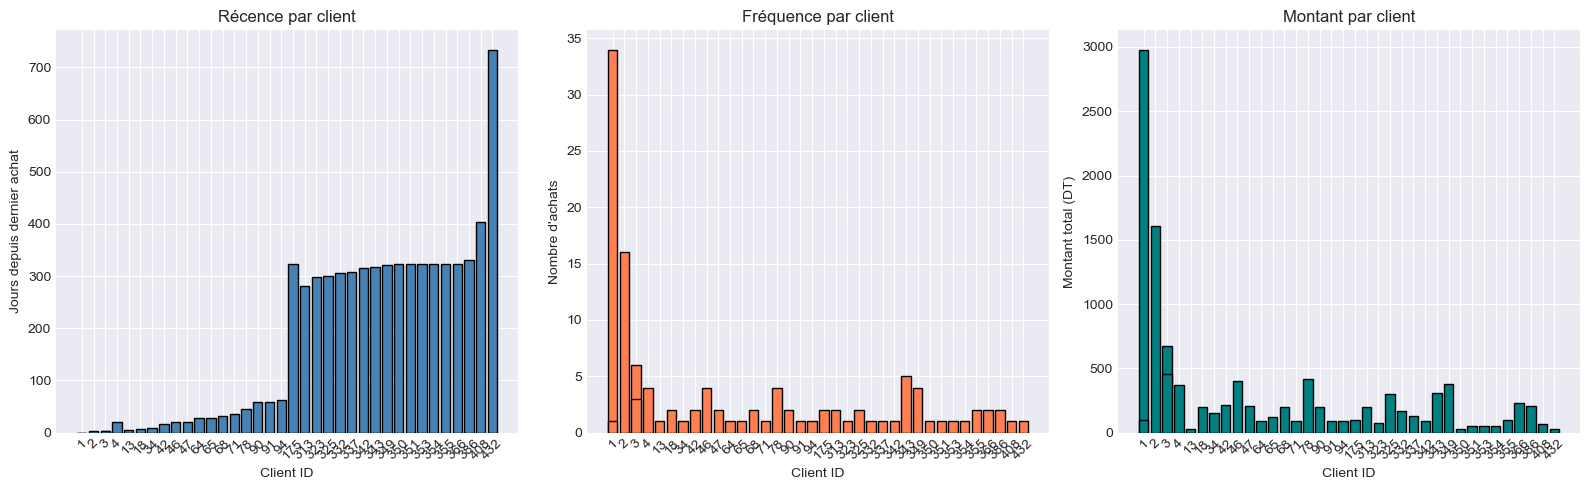

In [5]:
# CELLULE 2.4 : Graphique 1 - Distribution RFM

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Récence
axes[0].bar(rfm['client_id'].astype(str), rfm['recency'], color='steelblue', edgecolor='black')
axes[0].set_title('Récence par client', fontsize=12)
axes[0].set_xlabel('Client ID')
axes[0].set_ylabel('Jours depuis dernier achat')
axes[0].tick_params(axis='x', rotation=45)

# Fréquence
axes[1].bar(rfm['client_id'].astype(str), rfm['frequency'], color='coral', edgecolor='black')
axes[1].set_title('Fréquence par client', fontsize=12)
axes[1].set_xlabel('Client ID')
axes[1].set_ylabel("Nombre d'achats")
axes[1].tick_params(axis='x', rotation=45)

# Montant
axes[2].bar(rfm['client_id'].astype(str), rfm['monetary'], color='teal', edgecolor='black')
axes[2].set_title('Montant par client', fontsize=12)
axes[2].set_xlabel('Client ID')
axes[2].set_ylabel('Montant total (DT)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

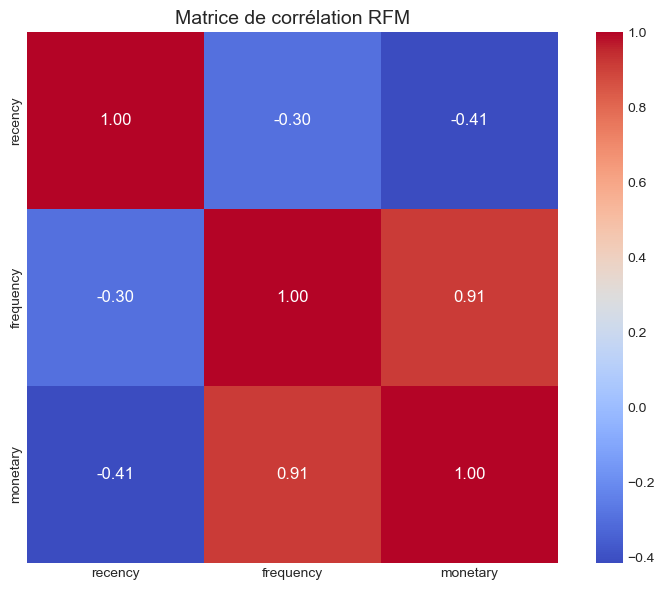


📊 INTERPRÉTATION DES CORRÉLATIONS :
   Récence ↔ Fréquence : -0.295
   Récence ↔ Montant   : -0.414
   Fréquence ↔ Montant : 0.914


In [9]:
# CELLULE 2.5 : Graphique 2 - Matrice de corrélation

if len(rfm) > 3:
    corr_matrix = rfm[['recency', 'frequency', 'monetary']].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, 
                annot_kws={'size': 12})
    plt.title('Matrice de corrélation RFM', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\n📊 INTERPRÉTATION DES CORRÉLATIONS :")
    print(f"   Récence ↔ Fréquence : {corr_matrix.loc['recency', 'frequency']:.3f}")
    print(f"   Récence ↔ Montant   : {corr_matrix.loc['recency', 'monetary']:.3f}")
    print(f"   Fréquence ↔ Montant : {corr_matrix.loc['frequency', 'monetary']:.3f}")
else:
    print("⚠️ Pas assez de clients pour la matrice de corrélation")


📊 SEGMENTATION CLIENTS

📊 RÉPARTITION DES SEGMENTS :
   😴 Dormants - Clients inactifs : 13 client(s)
   ⭐ Fidèles - Clients réguliers : 11 client(s)
   💰 VIP - Clients Premium : 9 client(s)
   🆕 Actifs - Clients récents : 5 client(s)

📋 DÉTAIL PAR CLIENT :
 client_id client_type  recency  frequency  monetary                       segment
         1         B2B        0        3.5    571.25       💰 VIP - Clients Premium
         1         B2C        0        1.0    100.00    🆕 Actifs - Clients récents
         2         B2B        4        3.5    571.25       💰 VIP - Clients Premium
         3         B2B        4        3.5    571.25       💰 VIP - Clients Premium
         3         B2C        4        3.0    459.00       💰 VIP - Clients Premium
         4         B2B       20        3.5    371.00       💰 VIP - Clients Premium
        13         B2C        6        1.0     30.00    🆕 Actifs - Clients récents
        18         B2C        7        2.0    199.80 ⭐ Fidèles - Clients régul

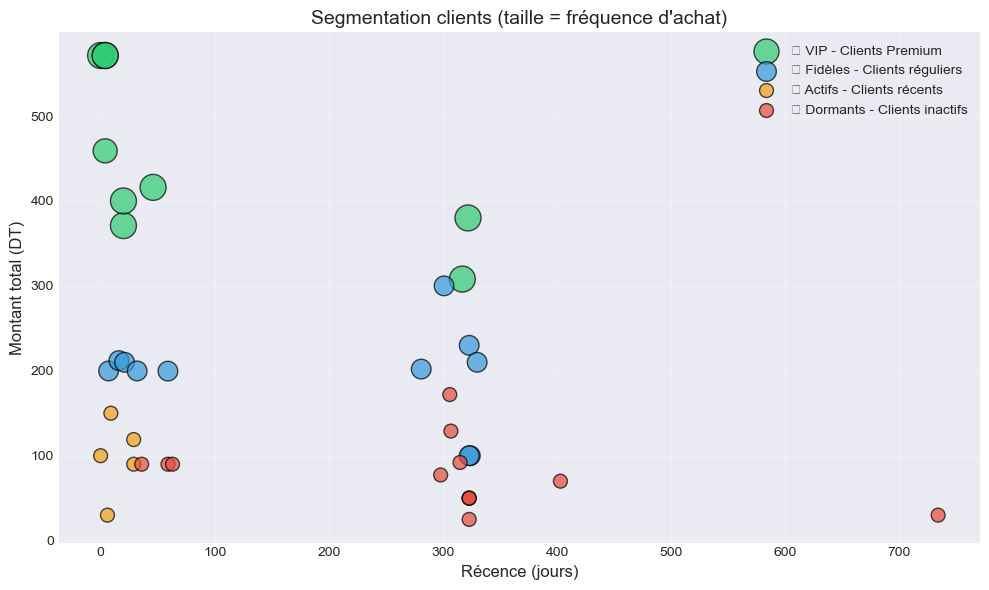

In [10]:
# CELLULE 2.6 : Segmentation clients

print("\n" + "="*70)
print("📊 SEGMENTATION CLIENTS")
print("="*70)

# Définir les segments en fonction des métriques
def define_segment(row):
    if row['frequency'] >= 3 and row['monetary'] > rfm['monetary'].mean():
        return '💰 VIP - Clients Premium'
    elif row['frequency'] >= 2:
        return '⭐ Fidèles - Clients réguliers'
    elif row['recency'] < 30:
        return '🆕 Actifs - Clients récents'
    else:
        return '😴 Dormants - Clients inactifs'

rfm['segment'] = rfm.apply(define_segment, axis=1)

print("\n📊 RÉPARTITION DES SEGMENTS :")
segment_counts = rfm['segment'].value_counts()
for seg, count in segment_counts.items():
    print(f"   {seg} : {count} client(s)")

print("\n📋 DÉTAIL PAR CLIENT :")
print(rfm[['client_id', 'client_type', 'recency', 'frequency', 'monetary', 'segment']].to_string(index=False))

# Graphique des segments
plt.figure(figsize=(10, 6))
colors_seg = {'💰 VIP - Clients Premium': '#2ecc71', 
              '⭐ Fidèles - Clients réguliers': '#3498db',
              '🆕 Actifs - Clients récents': '#f39c12',
              '😴 Dormants - Clients inactifs': '#e74c3c'}

for seg, color in colors_seg.items():
    data = rfm[rfm['segment'] == seg]
    plt.scatter(data['recency'], data['monetary'], s=data['frequency']*100, 
                c=color, label=seg, alpha=0.7, edgecolors='black')

plt.title('Segmentation clients (taille = fréquence d\'achat)', fontsize=14)
plt.xlabel('Récence (jours)', fontsize=12)
plt.ylabel('Montant total (DT)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


📊 VISUALISATIONS DU MODÈLE K-MEANS
✅ Nombre optimal de clusters : 10 (Score Silhouette max: 0.5970)
✅ Variance expliquée par PC1 : 75.46%
✅ Variance expliquée par PC2 : 19.86%
✅ Variance totale expliquée : 95.32%


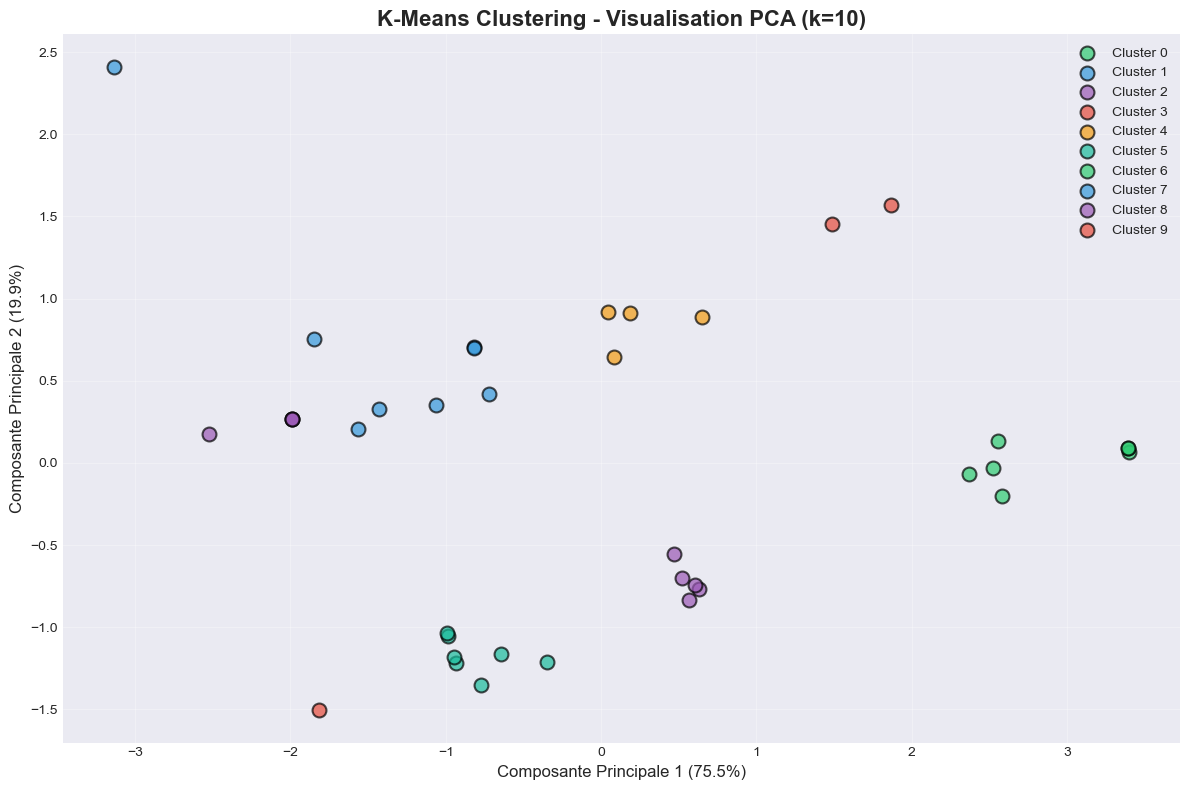

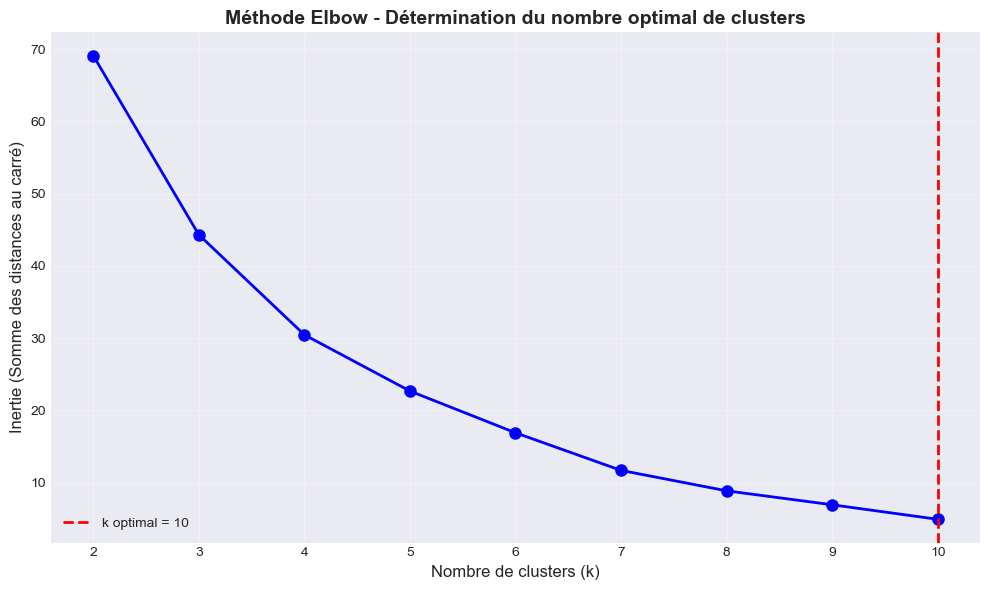

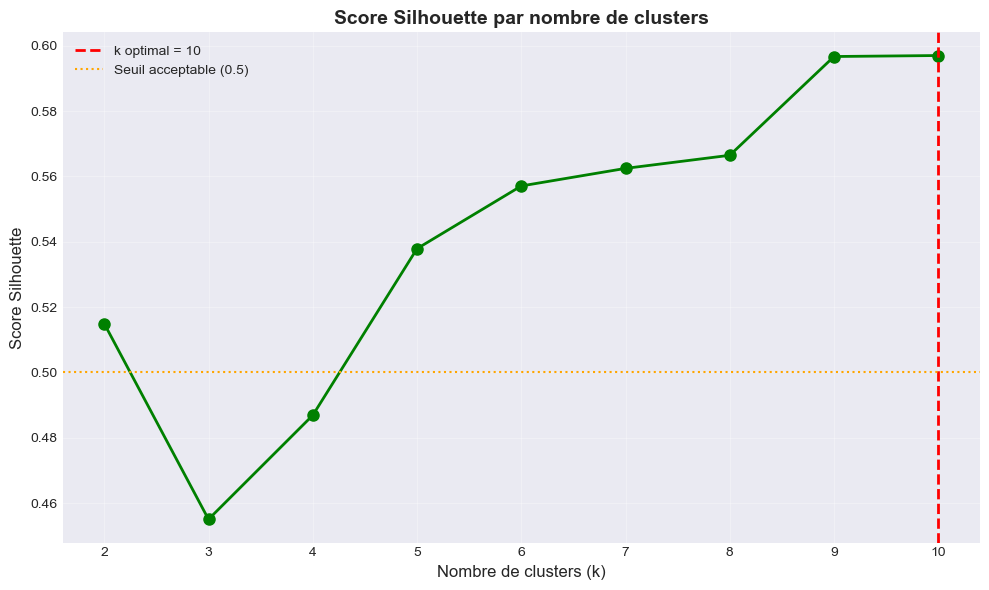

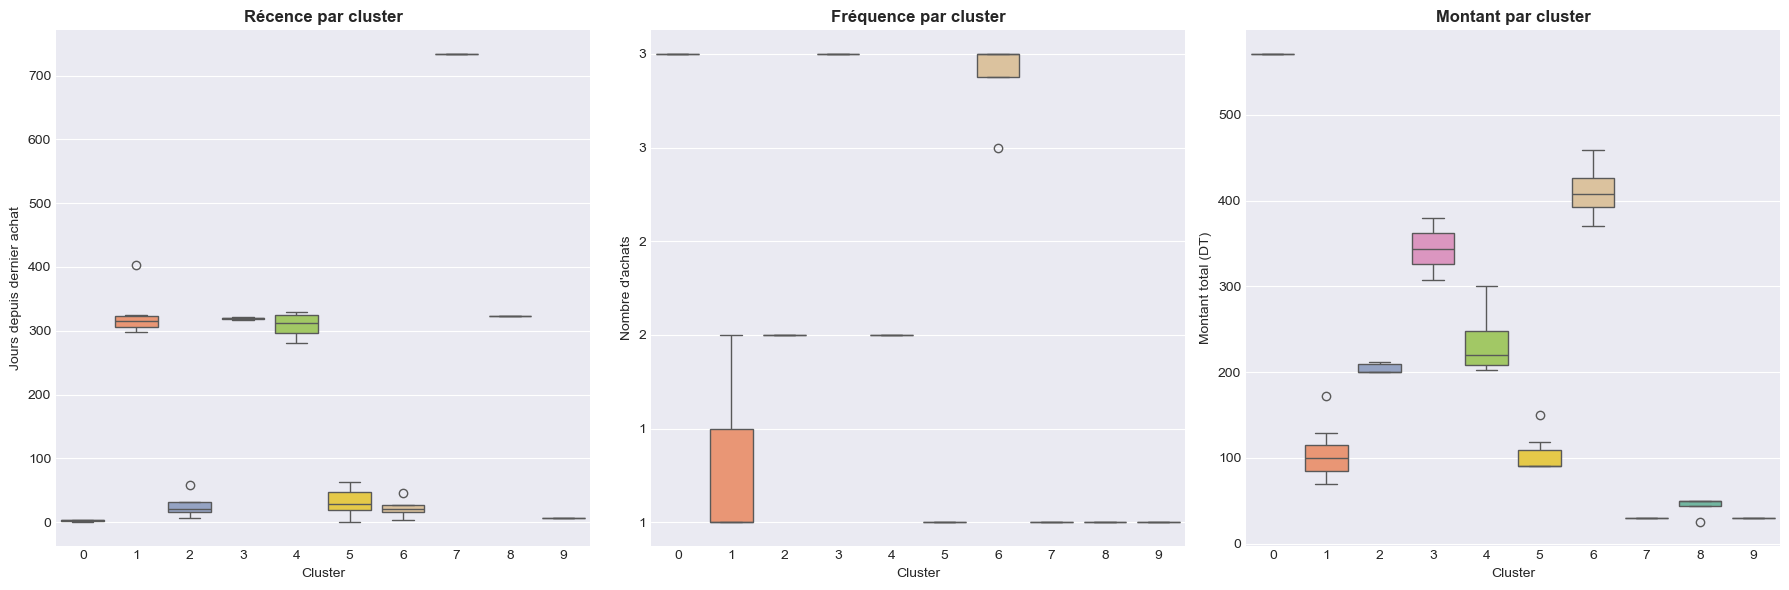

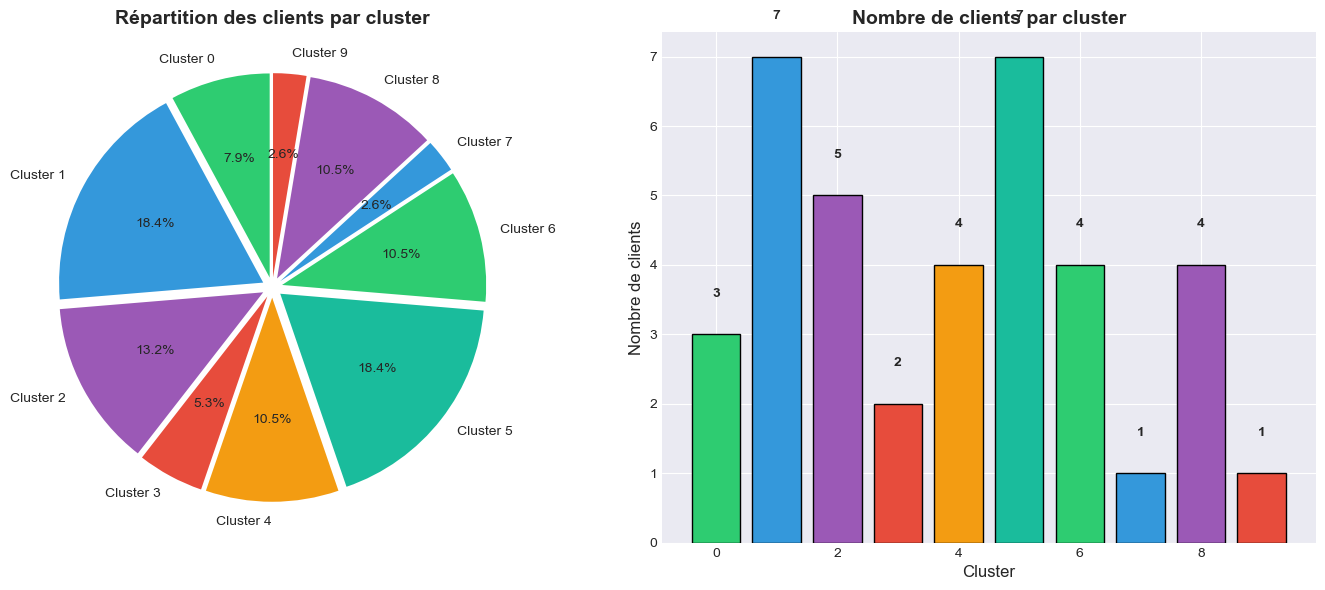

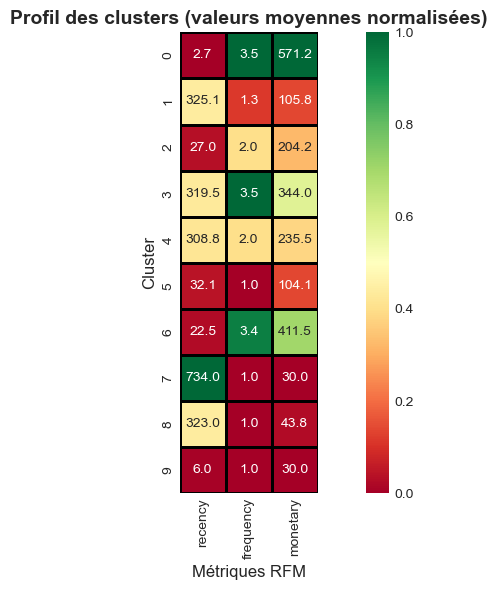


📊 PROFIL DÉTAILLÉ DES CLUSTERS

📌 CLUSTER 0 :
   👥 Nombre de clients : 3
   📅 Récence moyenne : 3 jours
   📦 Fréquence moyenne : 3.5 achats
   💰 Montant moyen : 571 DT
   🏷️  Type : CLIENTS ACTIFS (à fidéliser)

📌 CLUSTER 1 :
   👥 Nombre de clients : 7
   📅 Récence moyenne : 325 jours
   📦 Fréquence moyenne : 1.3 achats
   💰 Montant moyen : 106 DT
   🏷️  Type : CLIENTS DORMANTS (à réactiver)

📌 CLUSTER 2 :
   👥 Nombre de clients : 5
   📅 Récence moyenne : 27 jours
   📦 Fréquence moyenne : 2.0 achats
   💰 Montant moyen : 204 DT
   🏷️  Type : CLIENTS ACTIFS (à fidéliser)

📌 CLUSTER 3 :
   👥 Nombre de clients : 2
   📅 Récence moyenne : 320 jours
   📦 Fréquence moyenne : 3.5 achats
   💰 Montant moyen : 344 DT
   🏷️  Type : CLIENTS PREMIUM (valeur élevée)

📌 CLUSTER 4 :
   👥 Nombre de clients : 4
   📅 Récence moyenne : 309 jours
   📦 Fréquence moyenne : 2.0 achats
   💰 Montant moyen : 236 DT
   🏷️  Type : CLIENTS PREMIUM (valeur élevée)

📌 CLUSTER 5 :
   👥 Nombre de clients : 7
   📅 Récenc

In [14]:
# CELLULE 2.2.1 : VISUALISATIONS K-MEANS (CORRIGÉE)

print("\n" + "="*70)
print("📊 VISUALISATIONS DU MODÈLE K-MEANS")
print("="*70)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================
# 1. PRÉPARATION DES DONNÉES POUR VISUALISATION
# ============================================

# Si les données ne sont pas déjà normalisées
if 'X_scaled' not in locals():
    from sklearn.preprocessing import StandardScaler
    features = ['recency', 'frequency', 'monetary']
    X = rfm[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

# Déterminer le nombre optimal de clusters (Elbow + Silhouette)
inertia = []
silhouette_scores = []
k_range = range(2, min(11, len(rfm)))
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"✅ Nombre optimal de clusters : {optimal_k} (Score Silhouette max: {max(silhouette_scores):.4f})")

# Appliquer K-Means avec le k optimal
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['segment_kmeans'] = kmeans.fit_predict(X_scaled)

# Réduction PCA pour visualisation 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Ajouter les coordonnées PCA au DataFrame
rfm['pca_1'] = X_pca[:, 0]
rfm['pca_2'] = X_pca[:, 1]

print(f"✅ Variance expliquée par PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"✅ Variance expliquée par PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"✅ Variance totale expliquée : {pca.explained_variance_ratio_.sum()*100:.2f}%")

# ============================================
# 2. GRAPHIQUE 1 : VISUALISATION PCA DES CLUSTERS
# ============================================

plt.figure(figsize=(12, 8))

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c']

for i in range(optimal_k):
    mask = rfm['segment_kmeans'] == i
    plt.scatter(rfm.loc[mask, 'pca_1'], rfm.loc[mask, 'pca_2'], 
                c=colors[i % len(colors)], label=f'Cluster {i}', 
                s=100, alpha=0.7, edgecolors='black', linewidth=1.5)

plt.title(f'K-Means Clustering - Visualisation PCA (k={optimal_k})', fontsize=16, fontweight='bold')
plt.xlabel(f'Composante Principale 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Composante Principale 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 3. GRAPHIQUE 2 : MÉTHODE ELBOW
# ============================================

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'b-', marker='o', linewidth=2, markersize=8)
plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'k optimal = {optimal_k}')
plt.title('Méthode Elbow - Détermination du nombre optimal de clusters', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de clusters (k)', fontsize=12)
plt.ylabel('Inertie (Somme des distances au carré)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 4. GRAPHIQUE 3 : SCORE SILHOUETTE
# ============================================

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'g-', marker='o', linewidth=2, markersize=8)
plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, label=f'k optimal = {optimal_k}')
plt.axhline(y=0.5, color='orange', linestyle=':', linewidth=1.5, label='Seuil acceptable (0.5)')
plt.title('Score Silhouette par nombre de clusters', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de clusters (k)', fontsize=12)
plt.ylabel('Score Silhouette', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 5. GRAPHIQUE 4 : BOXPLOTS PAR CLUSTER
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Récence
sns.boxplot(data=rfm, x='segment_kmeans', y='recency', ax=axes[0], palette='Set2')
axes[0].set_title('Récence par cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Jours depuis dernier achat')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# Fréquence
sns.boxplot(data=rfm, x='segment_kmeans', y='frequency', ax=axes[1], palette='Set2')
axes[1].set_title('Fréquence par cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel("Nombre d'achats")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# Montant
sns.boxplot(data=rfm, x='segment_kmeans', y='monetary', ax=axes[2], palette='Set2')
axes[2].set_title('Montant par cluster', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Montant total (DT)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

plt.tight_layout()
plt.show()

# ============================================
# 6. GRAPHIQUE 5 : RÉPARTITION DES CLIENTS
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Camembert
segment_counts = rfm['segment_kmeans'].value_counts().sort_index()
colors_pie = [colors[i % len(colors)] for i in segment_counts.index]
axes[0].pie(segment_counts.values, labels=[f'Cluster {i}' for i in segment_counts.index], 
            autopct='%1.1f%%', colors=colors_pie, startangle=90, explode=[0.05]*len(segment_counts))
axes[0].set_title('Répartition des clients par cluster', fontsize=14, fontweight='bold')

# Barres
bars = axes[1].bar(segment_counts.index, segment_counts.values, color=colors_pie, edgecolor='black')
axes[1].set_title('Nombre de clients par cluster', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Nombre de clients', fontsize=12)
for bar, val in zip(bars, segment_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 7. GRAPHIQUE 6 : PROFIL DES CLUSTERS (Heatmap)
# ============================================

cluster_profiles = rfm.groupby('segment_kmeans').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean'
}).round(2)

# Normaliser pour la heatmap
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles_norm, annot=cluster_profiles, fmt='.1f', cmap='RdYlGn', 
            linewidths=1, linecolor='black', square=True)
plt.title('Profil des clusters (valeurs moyennes normalisées)', fontsize=14, fontweight='bold')
plt.xlabel('Métriques RFM', fontsize=12)
plt.ylabel('Cluster', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# 8. RAPPORT DES CLUSTERS
# ============================================

print("\n" + "="*70)
print("📊 PROFIL DÉTAILLÉ DES CLUSTERS")
print("="*70)

for i in range(optimal_k):
    data = rfm[rfm['segment_kmeans'] == i]
    print(f"\n📌 CLUSTER {i} :")
    print(f"   👥 Nombre de clients : {len(data)}")
    print(f"   📅 Récence moyenne : {data['recency'].mean():.0f} jours")
    print(f"   📦 Fréquence moyenne : {data['frequency'].mean():.1f} achats")
    print(f"   💰 Montant moyen : {data['monetary'].mean():.0f} DT")
    
    # Interprétation
    if data['recency'].mean() < rfm['recency'].mean() and data['frequency'].mean() > rfm['frequency'].mean():
        print(f"   🏷️  Type : CLIENTS ACTIFS (à fidéliser)")
    elif data['monetary'].mean() > rfm['monetary'].mean():
        print(f"   🏷️  Type : CLIENTS PREMIUM (valeur élevée)")
    elif data['recency'].mean() > rfm['recency'].mean() * 1.5:
        print(f"   🏷️  Type : CLIENTS DORMANTS (à réactiver)")
    else:
        print(f"   🏷️  Type : CLIENTS STANDARD")

print("\n" + "="*70)
print("✅ Visualisations K-Means terminées")
print("="*70)


📊 MODÈLE 2 : HIERARCHICAL CLUSTERING


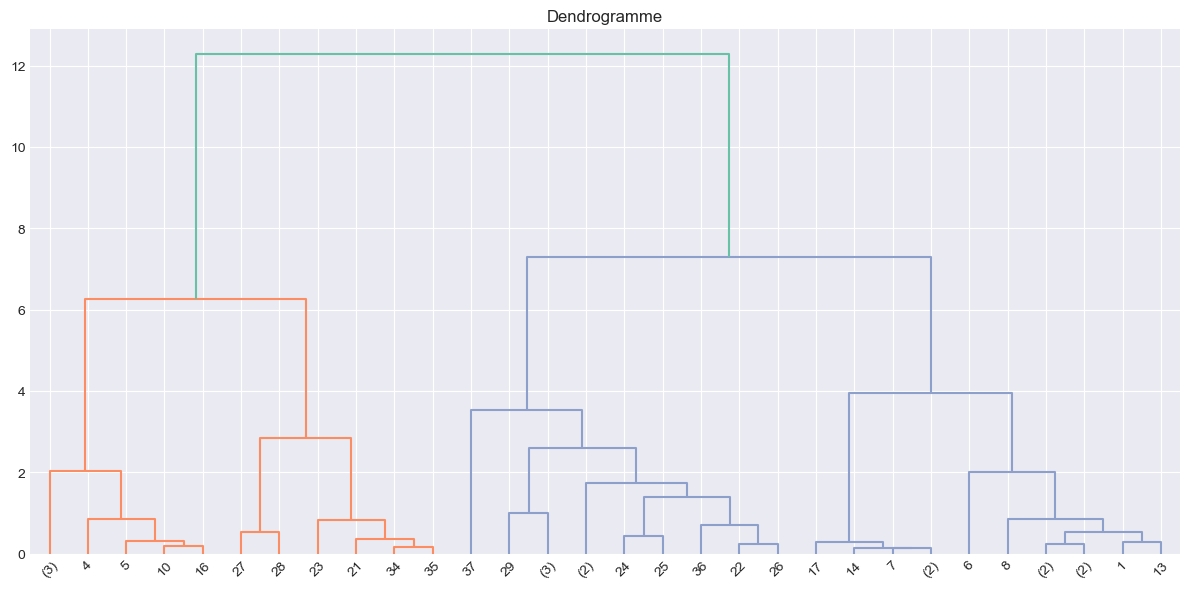

Silhouette: 0.5970


In [15]:
# CELLULE 2.3 : MODÈLE 2 - HIERARCHICAL CLUSTERING

print("\n" + "="*70)
print("📊 MODÈLE 2 : HIERARCHICAL CLUSTERING")
print("="*70)

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrogramme
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title('Dendrogramme')
plt.tight_layout()
plt.show()

# Application
hier = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
rfm['segment_hier'] = hier.fit_predict(X_scaled)

silhouette_hier = silhouette_score(X_scaled, rfm['segment_hier'])
print(f"Silhouette: {silhouette_hier:.4f}")


📊 VISUALISATIONS DU MODÈLE DBSCAN
✅ Variance expliquée par PC1 : 75.46%
✅ Variance expliquée par PC2 : 19.86%
✅ Meilleur eps : 0.5
✅ Clusters trouvés : 8
✅ Points de bruit : 10
✅ Score Silhouette DBSCAN : 0.7611


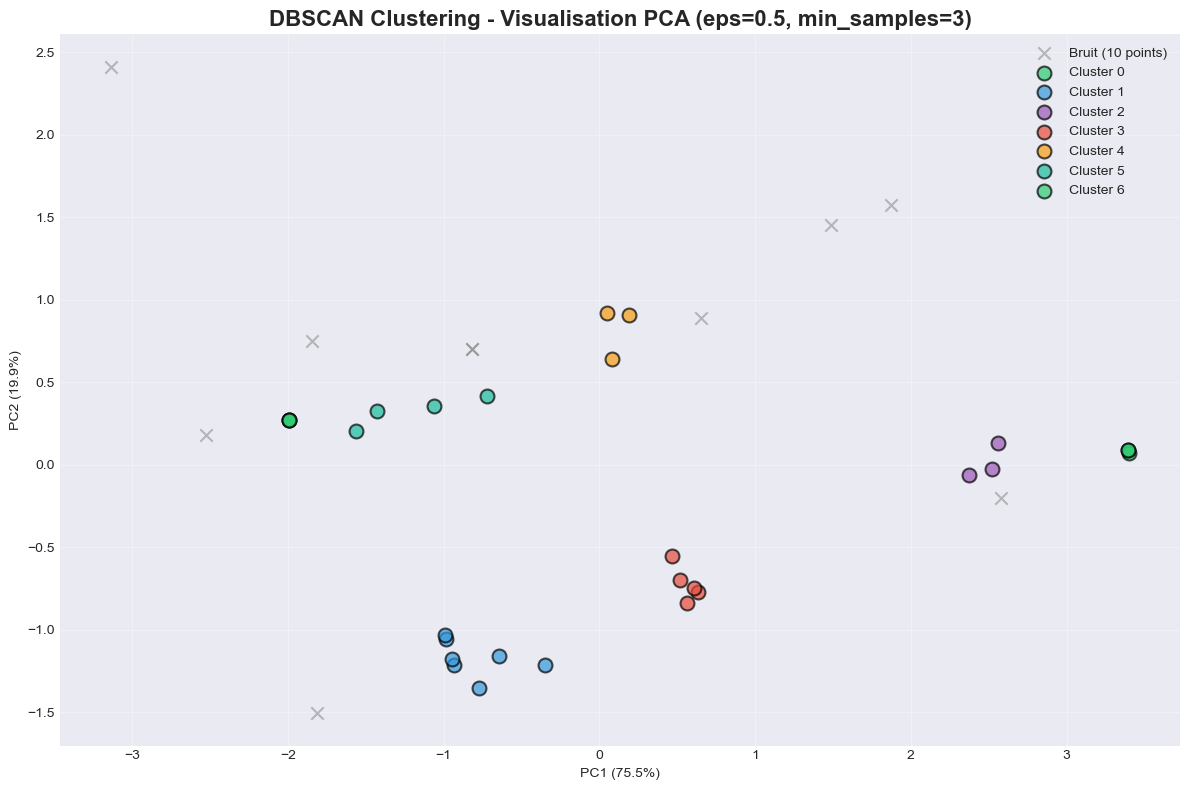

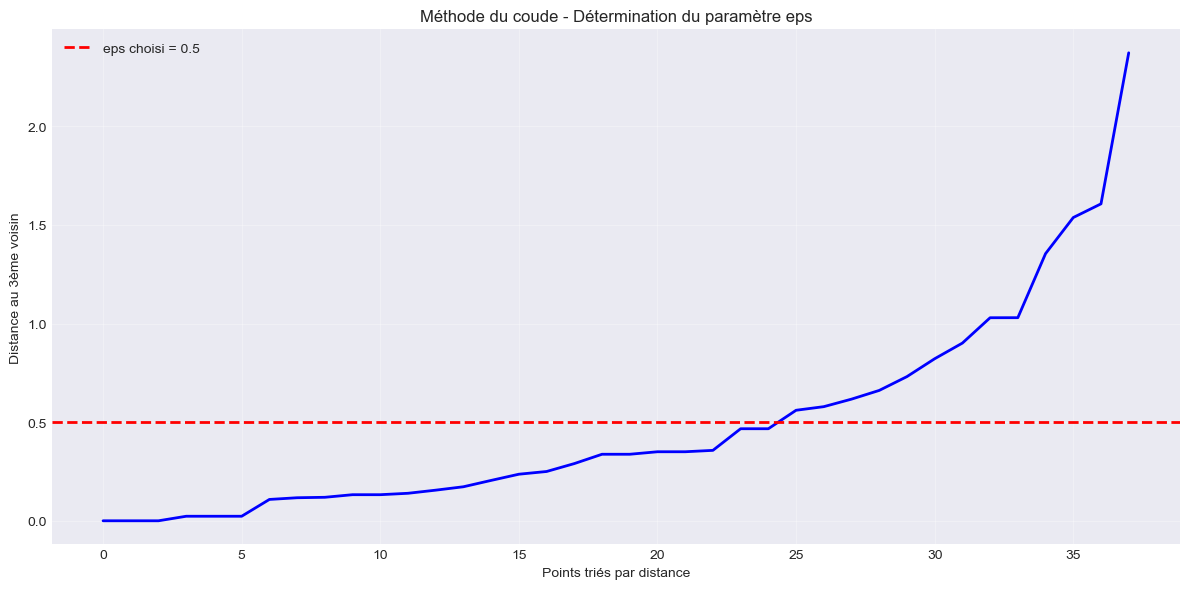

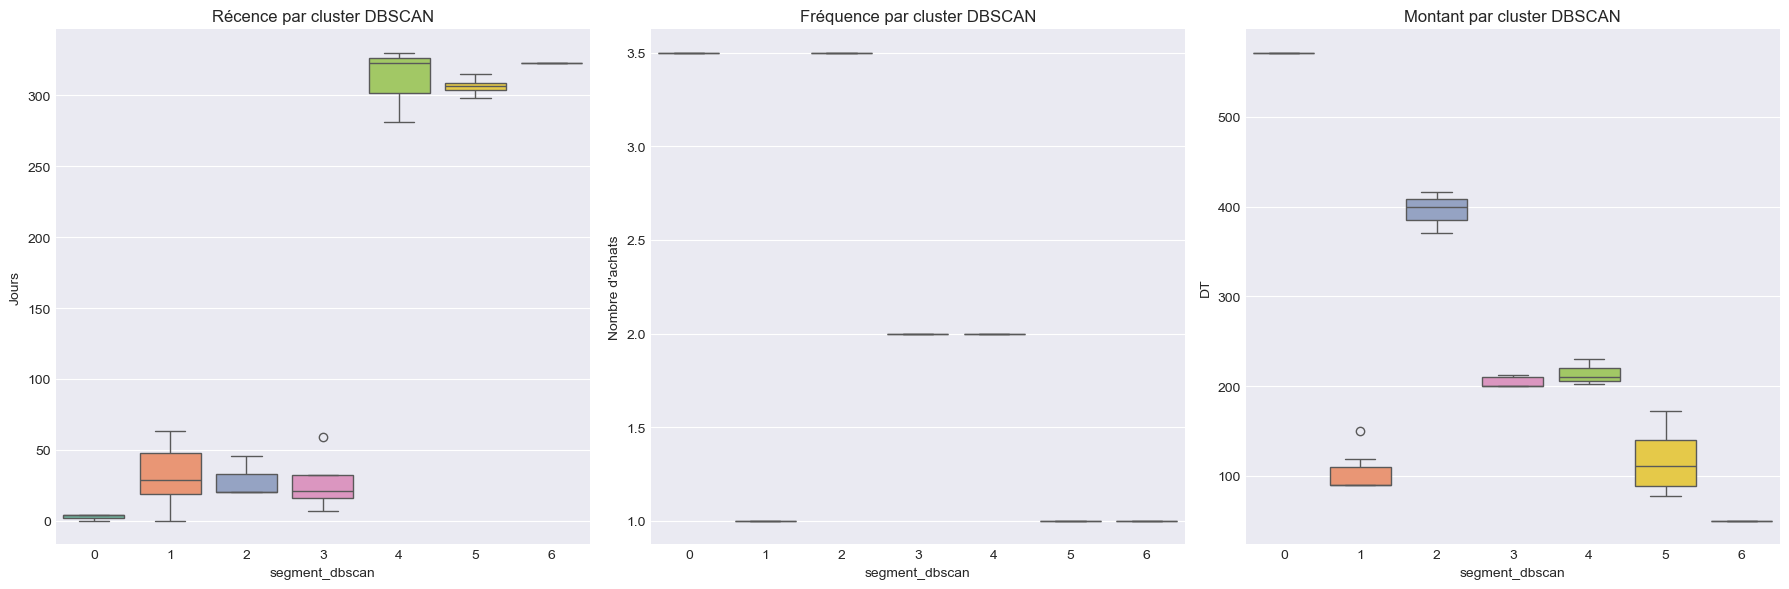

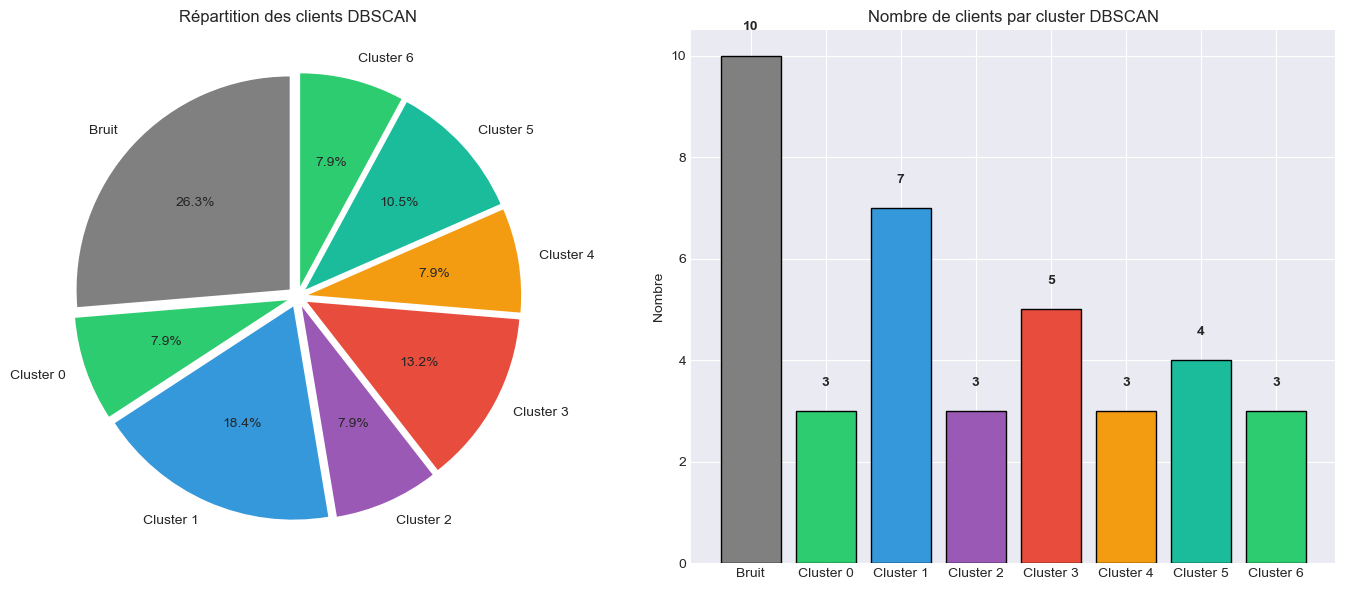

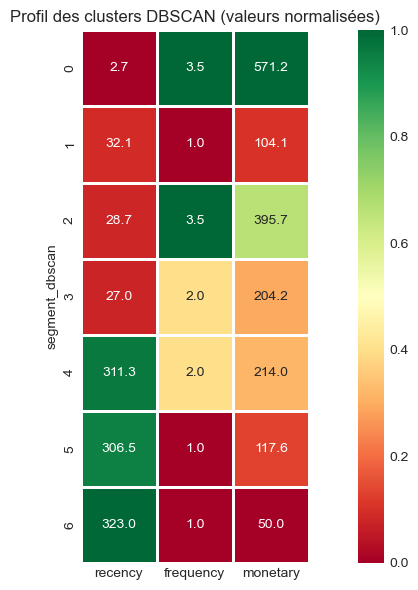


📊 PROFIL DÉTAILLÉ DES CLUSTERS DBSCAN

🔴 BRUIT (Points isolés) : 10 clients
   Récence moyenne : 306 jours
   Fréquence moyenne : 2.0 achats
   Montant moyen : 180 DT

📌 CLUSTER 0 : 3 clients
   Récence moyenne : 3 jours
   Fréquence moyenne : 3.5 achats
   Montant moyen : 571 DT
   🏷️  Type : CLIENTS ACTIFS

📌 CLUSTER 1 : 7 clients
   Récence moyenne : 32 jours
   Fréquence moyenne : 1.0 achats
   Montant moyen : 104 DT
   🏷️  Type : CLIENTS STANDARD

📌 CLUSTER 2 : 3 clients
   Récence moyenne : 29 jours
   Fréquence moyenne : 3.5 achats
   Montant moyen : 396 DT
   🏷️  Type : CLIENTS ACTIFS

📌 CLUSTER 3 : 5 clients
   Récence moyenne : 27 jours
   Fréquence moyenne : 2.0 achats
   Montant moyen : 204 DT
   🏷️  Type : CLIENTS ACTIFS

📌 CLUSTER 4 : 3 clients
   Récence moyenne : 311 jours
   Fréquence moyenne : 2.0 achats
   Montant moyen : 214 DT
   🏷️  Type : CLIENTS PREMIUM

📌 CLUSTER 5 : 4 clients
   Récence moyenne : 306 jours
   Fréquence moyenne : 1.0 achats
   Montant moyen : 

In [17]:
# CELLULE 2.4.1 : VISUALISATIONS DBSCAN (CORRIGÉE)

print("\n" + "="*70)
print("📊 VISUALISATIONS DU MODÈLE DBSCAN")
print("="*70)

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ============================================
# 1. PRÉPARATION DES DONNÉES
# ============================================

# S'assurer que X_scaled existe
if 'X_scaled' not in locals():
    print("⚠️ X_scaled non trouvé, recalcul...")
    features = ['recency', 'frequency', 'monetary']
    X = rfm[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

# Réduction PCA pour visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
rfm['pca_1'] = X_pca[:, 0]
rfm['pca_2'] = X_pca[:, 1]

print(f"✅ Variance expliquée par PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"✅ Variance expliquée par PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%")

# ============================================
# 2. OPTIMISATION DES PARAMÈTRES DBSCAN
# ============================================

# Méthode du coude pour choisir eps
neighbors = NearestNeighbors(n_neighbors=3)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 2], axis=0)

best_eps = 0.8
best_silhouette = -1
best_labels = None
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0]

for eps in eps_values:
    dbscan_test = DBSCAN(eps=eps, min_samples=3)
    labels = dbscan_test.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters >= 2 and n_clusters <= 10:
        try:
            sil = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
            if sil > best_silhouette:
                best_silhouette = sil
                best_eps = eps
                best_labels = labels
        except:
            pass

# Appliquer DBSCAN avec le meilleur eps
dbscan = DBSCAN(eps=best_eps, min_samples=3)
rfm['segment_dbscan'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(rfm['segment_dbscan'])) - (1 if -1 in rfm['segment_dbscan'] else 0)
n_noise_db = (rfm['segment_dbscan'] == -1).sum()

print(f"✅ Meilleur eps : {best_eps}")
print(f"✅ Clusters trouvés : {n_clusters_db}")
print(f"✅ Points de bruit : {n_noise_db}")

if n_clusters_db >= 2:
    mask = rfm['segment_dbscan'] != -1
    best_silhouette_db = silhouette_score(X_scaled[mask], rfm.loc[mask, 'segment_dbscan'])
    print(f"✅ Score Silhouette DBSCAN : {best_silhouette_db:.4f}")
else:
    best_silhouette_db = -1
    print("⚠️ Pas assez de clusters pour calculer Silhouette")

# ============================================
# 3. GRAPHIQUE 1 : VISUALISATION PCA DES CLUSTERS DBSCAN
# ============================================

plt.figure(figsize=(12, 8))
colors_db = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c']

unique_labels = sorted(rfm['segment_dbscan'].unique())
for label in unique_labels:
    mask = rfm['segment_dbscan'] == label
    if label == -1:
        plt.scatter(rfm.loc[mask, 'pca_1'], rfm.loc[mask, 'pca_2'], 
                    c='gray', label=f'Bruit ({mask.sum()} points)', 
                    s=80, alpha=0.5, edgecolors='black', marker='x')
    else:
        plt.scatter(rfm.loc[mask, 'pca_1'], rfm.loc[mask, 'pca_2'], 
                    c=colors_db[label % len(colors_db)], label=f'Cluster {label}', 
                    s=100, alpha=0.7, edgecolors='black', linewidth=1.5)

plt.title(f'DBSCAN Clustering - Visualisation PCA (eps={best_eps}, min_samples=3)', fontsize=16, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 4. GRAPHIQUE 2 : MÉTHODE DU COUDE (CHOIX DE EPS)
# ============================================

plt.figure(figsize=(12, 6))
plt.plot(distances, 'b-', linewidth=2)
plt.axhline(y=best_eps, color='red', linestyle='--', linewidth=2, label=f'eps choisi = {best_eps}')
plt.title('Méthode du coude - Détermination du paramètre eps')
plt.xlabel('Points triés par distance')
plt.ylabel('Distance au 3ème voisin')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 5. GRAPHIQUE 3 : BOXPLOTS PAR CLUSTER (sans bruit)
# ============================================

dbscan_no_noise = rfm[rfm['segment_dbscan'] != -1]
if len(dbscan_no_noise) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    sns.boxplot(data=dbscan_no_noise, x='segment_dbscan', y='recency', ax=axes[0], palette='Set2')
    axes[0].set_title('Récence par cluster DBSCAN')
    axes[0].set_ylabel('Jours')
    sns.boxplot(data=dbscan_no_noise, x='segment_dbscan', y='frequency', ax=axes[1], palette='Set2')
    axes[1].set_title('Fréquence par cluster DBSCAN')
    axes[1].set_ylabel('Nombre d\'achats')
    sns.boxplot(data=dbscan_no_noise, x='segment_dbscan', y='monetary', ax=axes[2], palette='Set2')
    axes[2].set_title('Montant par cluster DBSCAN')
    axes[2].set_ylabel('DT')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Pas de clusters sans bruit pour les boxplots")

# ============================================
# 6. GRAPHIQUE 4 : RÉPARTITION DES CLIENTS
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
dbscan_counts = rfm['segment_dbscan'].value_counts().sort_index()
labels_db = []
values_db = []
colors_db_pie = []
for label, count in dbscan_counts.items():
    if label == -1:
        labels_db.append('Bruit')
        colors_db_pie.append('gray')
    else:
        labels_db.append(f'Cluster {label}')
        colors_db_pie.append(colors_db[label % len(colors_db)])
    values_db.append(count)

axes[0].pie(values_db, labels=labels_db, autopct='%1.1f%%', colors=colors_db_pie, startangle=90, explode=[0.05]*len(labels_db))
axes[0].set_title('Répartition des clients DBSCAN')
bars = axes[1].bar(labels_db, values_db, color=colors_db_pie, edgecolor='black')
axes[1].set_title('Nombre de clients par cluster DBSCAN')
axes[1].set_ylabel('Nombre')
for bar, val in zip(bars, values_db):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 7. HEATMAP DES PROFILS (clusters DBSCAN)
# ============================================

if len(dbscan_no_noise) > 1:
    cluster_profiles_db = dbscan_no_noise.groupby('segment_dbscan')[['recency', 'frequency', 'monetary']].mean().round(2)
    cluster_profiles_db_norm = (cluster_profiles_db - cluster_profiles_db.min()) / (cluster_profiles_db.max() - cluster_profiles_db.min())
    plt.figure(figsize=(10, 6))
    sns.heatmap(cluster_profiles_db_norm, annot=cluster_profiles_db, fmt='.1f', cmap='RdYlGn', linewidths=1, square=True)
    plt.title('Profil des clusters DBSCAN (valeurs normalisées)')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Pas assez de clusters pour la heatmap")

# ============================================
# 8. RAPPORT DES CLUSTERS DBSCAN
# ============================================

print("\n" + "="*70)
print("📊 PROFIL DÉTAILLÉ DES CLUSTERS DBSCAN")
print("="*70)
for label in sorted(rfm['segment_dbscan'].unique()):
    data = rfm[rfm['segment_dbscan'] == label]
    if label == -1:
        print(f"\n🔴 BRUIT (Points isolés) : {len(data)} clients")
        print(f"   Récence moyenne : {data['recency'].mean():.0f} jours")
        print(f"   Fréquence moyenne : {data['frequency'].mean():.1f} achats")
        print(f"   Montant moyen : {data['monetary'].mean():.0f} DT")
    else:
        print(f"\n📌 CLUSTER {label} : {len(data)} clients")
        print(f"   Récence moyenne : {data['recency'].mean():.0f} jours")
        print(f"   Fréquence moyenne : {data['frequency'].mean():.1f} achats")
        print(f"   Montant moyen : {data['monetary'].mean():.0f} DT")
        if data['recency'].mean() < rfm['recency'].mean() and data['frequency'].mean() > rfm['frequency'].mean():
            print(f"   🏷️  Type : CLIENTS ACTIFS")
        elif data['monetary'].mean() > rfm['monetary'].mean():
            print(f"   🏷️  Type : CLIENTS PREMIUM")
        elif data['recency'].mean() > rfm['recency'].mean() * 1.5:
            print(f"   🏷️  Type : CLIENTS DORMANTS")
        else:
            print(f"   🏷️  Type : CLIENTS STANDARD")

print("\n✅ Visualisations DBSCAN terminées")


📊 VISUALISATIONS DU MODÈLE GMM (Gaussian Mixture Model)
✅ Variance expliquée par PC1 : 75.46%
✅ Variance expliquée par PC2 : 19.86%
✅ Nombre optimal de composants : 10 (BIC = -270.12)
✅ Score Silhouette GMM : 0.6272


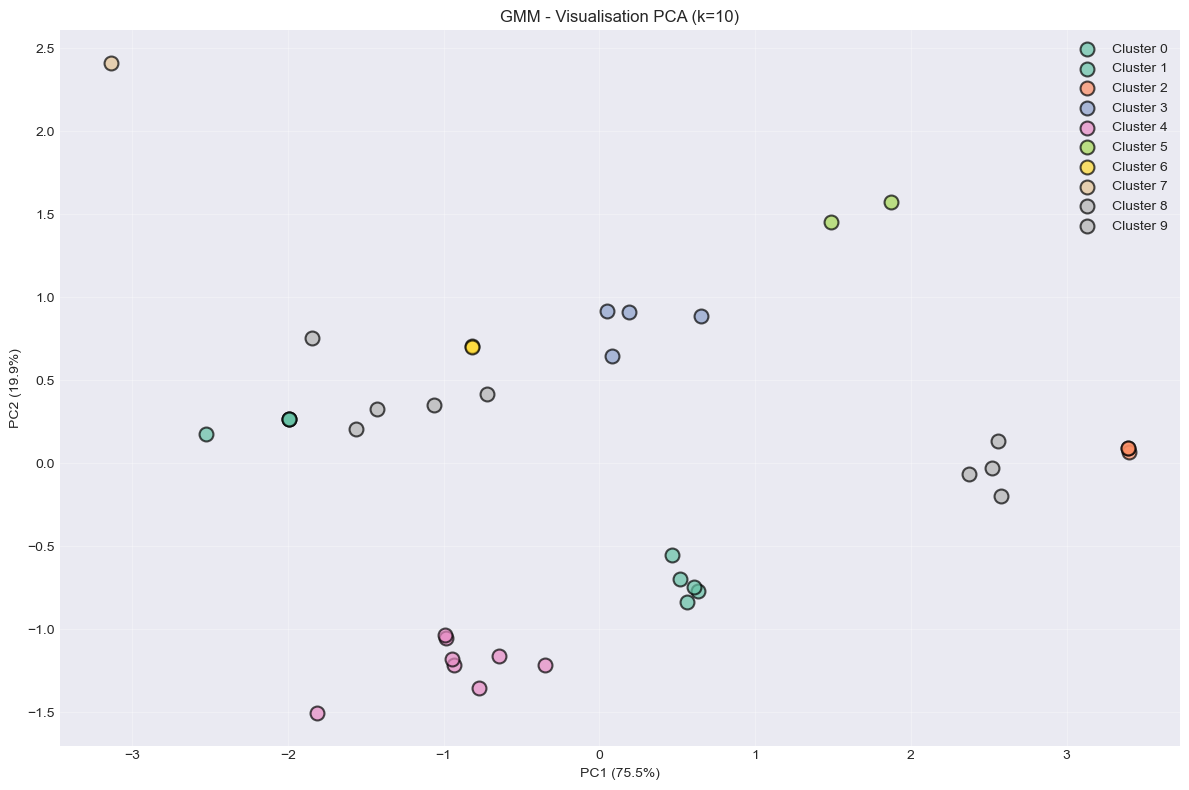

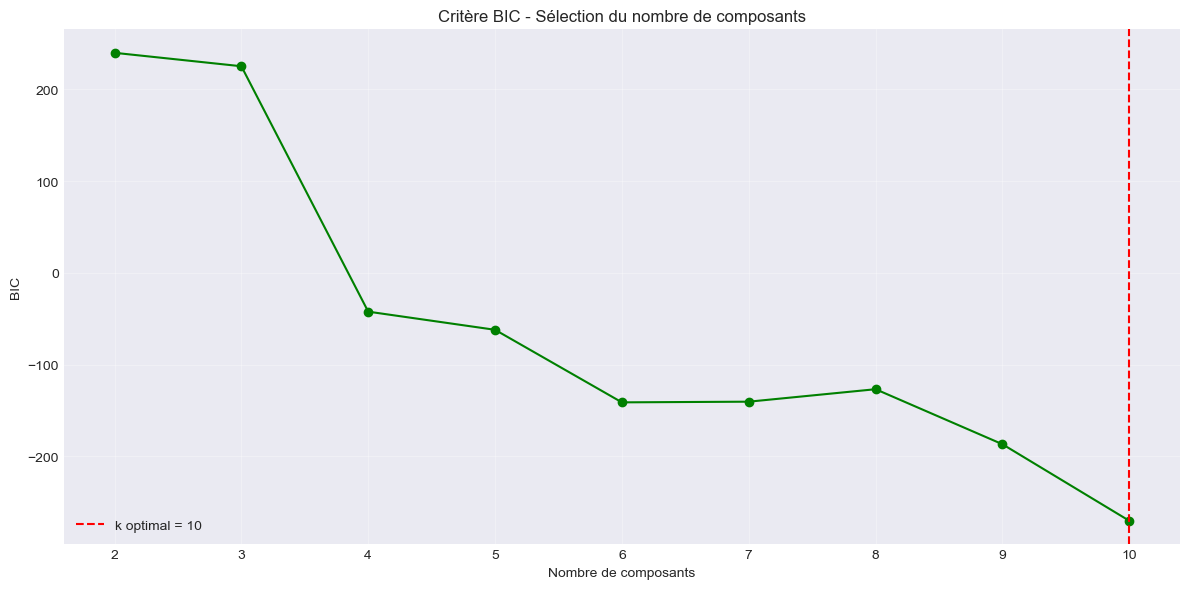

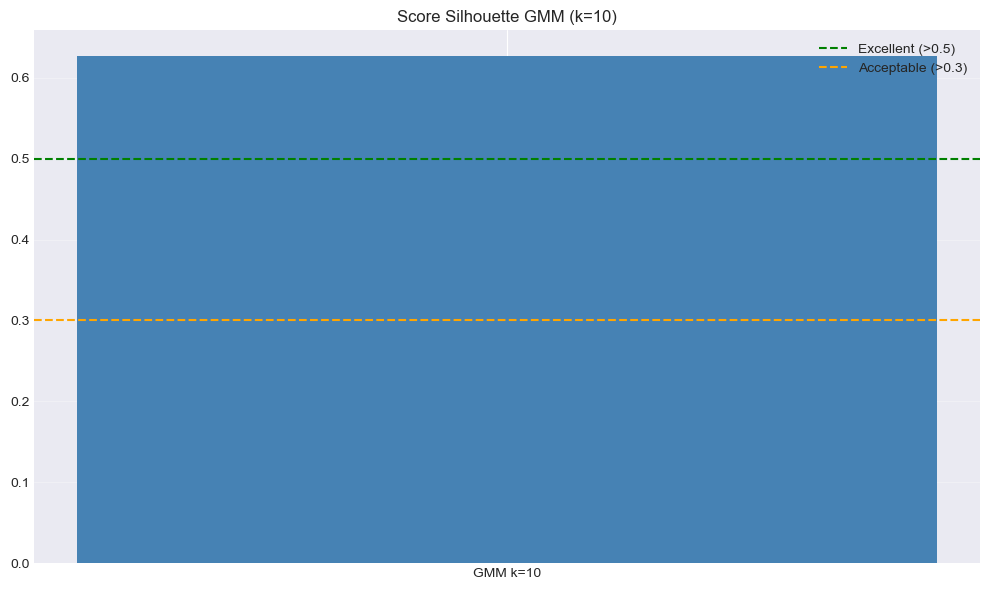

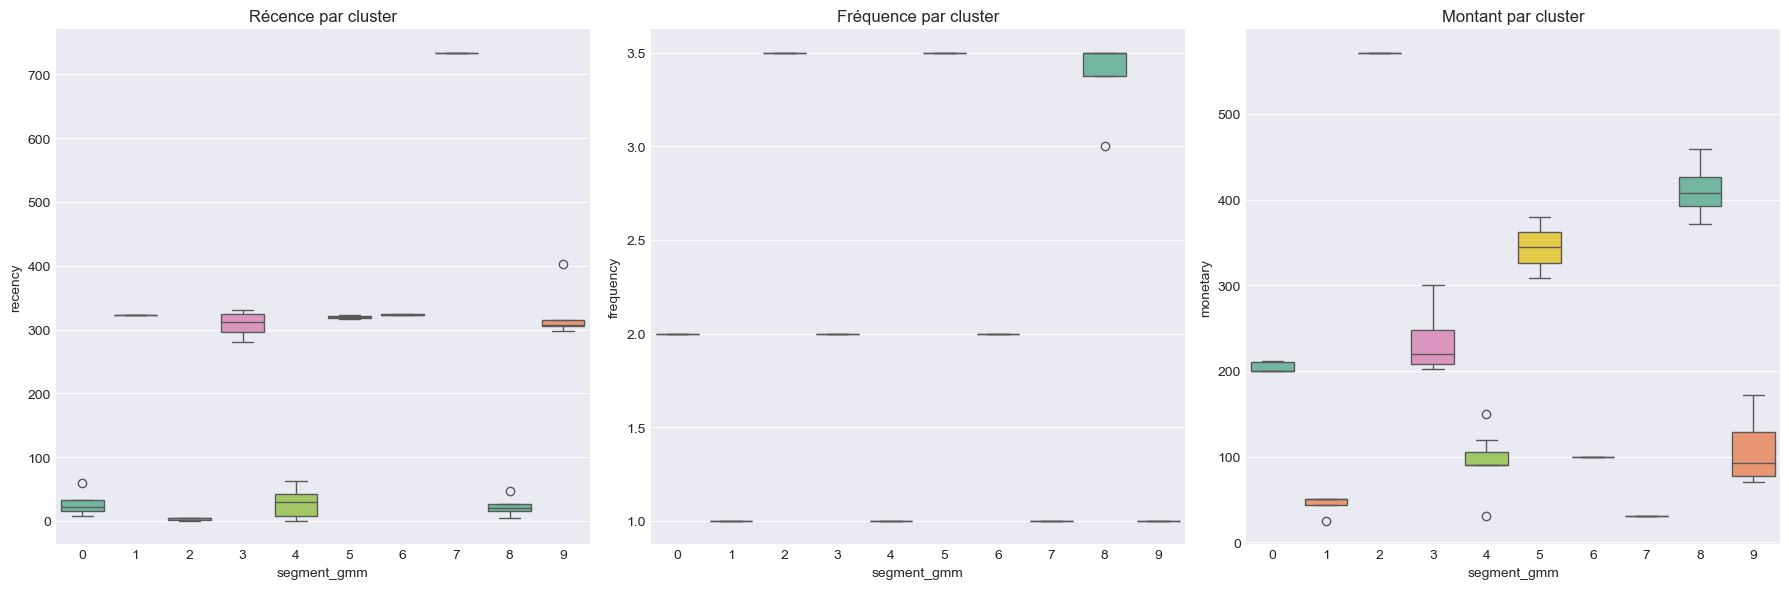

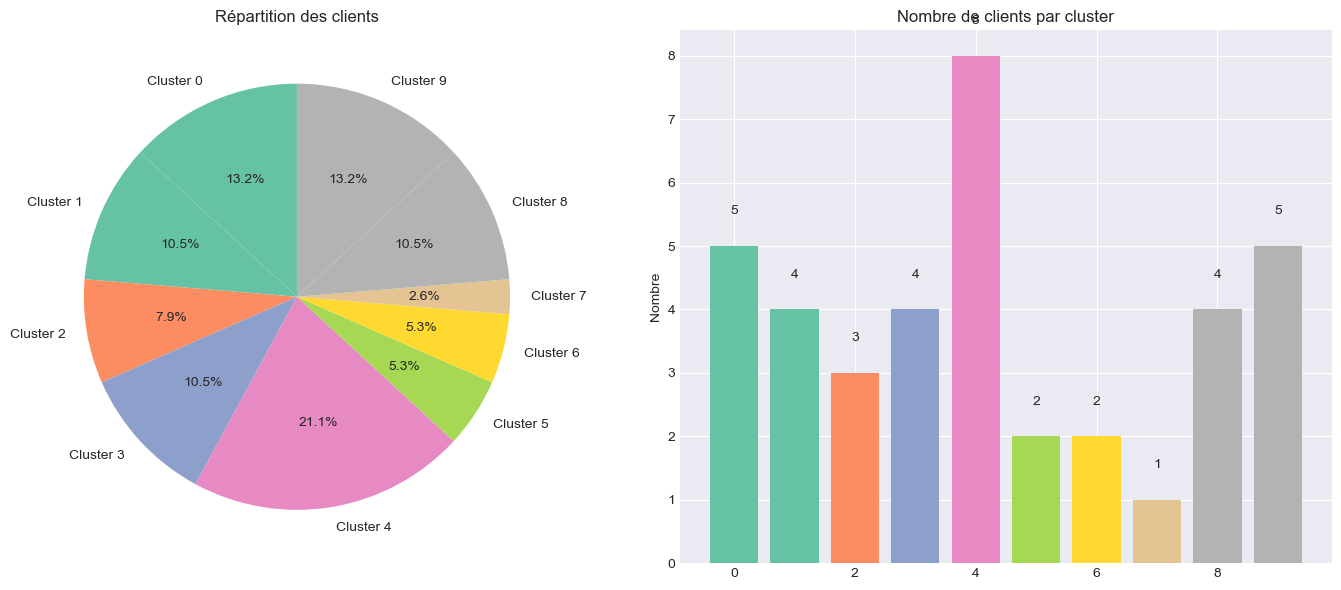

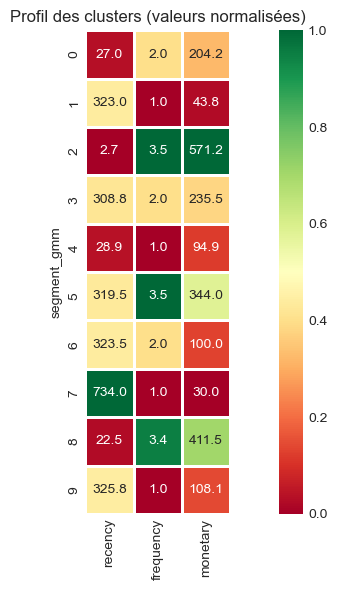


📊 PROFIL DES CLUSTERS GMM

Cluster 0 (5 clients):
   Récence: 27 jours
   Fréquence: 2.0 achats
   Montant: 204 DT
   → Clients actifs

Cluster 1 (4 clients):
   Récence: 323 jours
   Fréquence: 1.0 achats
   Montant: 44 DT
   → Clients dormants

Cluster 2 (3 clients):
   Récence: 3 jours
   Fréquence: 3.5 achats
   Montant: 571 DT
   → Clients actifs

Cluster 3 (4 clients):
   Récence: 309 jours
   Fréquence: 2.0 achats
   Montant: 236 DT
   → Clients premium

Cluster 4 (8 clients):
   Récence: 29 jours
   Fréquence: 1.0 achats
   Montant: 95 DT
   → Clients standard

Cluster 5 (2 clients):
   Récence: 320 jours
   Fréquence: 3.5 achats
   Montant: 344 DT
   → Clients premium

Cluster 6 (2 clients):
   Récence: 324 jours
   Fréquence: 2.0 achats
   Montant: 100 DT
   → Clients dormants

Cluster 7 (1 clients):
   Récence: 734 jours
   Fréquence: 1.0 achats
   Montant: 30 DT
   → Clients dormants

Cluster 8 (4 clients):
   Récence: 22 jours
   Fréquence: 3.4 achats
   Montant: 412 DT
 

In [19]:
# CELLULE 2.5.1 : VISUALISATIONS GMM (CORRIGÉE)

print("\n" + "="*70)
print("📊 VISUALISATIONS DU MODÈLE GMM (Gaussian Mixture Model)")
print("="*70)

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ============================================
# 1. PRÉPARATION DES DONNÉES
# ============================================

# S'assurer que X_scaled existe
if 'X_scaled' not in locals():
    print("⚠️ X_scaled non trouvé, recalcul...")
    features = ['recency', 'frequency', 'monetary']
    X = rfm[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

# Réduction PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
rfm['pca_1'] = X_pca[:, 0]
rfm['pca_2'] = X_pca[:, 1]

print(f"✅ Variance expliquée par PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"✅ Variance expliquée par PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%")

# ============================================
# 2. DÉTERMINATION DU NOMBRE OPTIMAL DE COMPOSANTS (GMM)
# ============================================

k_range_gmm = range(2, min(11, len(rfm)))
bic_scores = []
best_bic = np.inf
best_k_gmm = 2

for k in k_range_gmm:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bic = gmm.bic(X_scaled)
    bic_scores.append(bic)
    if bic < best_bic:
        best_bic = bic
        best_k_gmm = k

print(f"✅ Nombre optimal de composants : {best_k_gmm} (BIC = {best_bic:.2f})")

# ============================================
# 3. APPLICATION DU MODÈLE GMM
# ============================================

gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
rfm['segment_gmm'] = gmm.fit_predict(X_scaled)

silhouette_gmm = silhouette_score(X_scaled, rfm['segment_gmm'])
print(f"✅ Score Silhouette GMM : {silhouette_gmm:.4f}")

# ============================================
# 4. GRAPHIQUE 1 : VISUALISATION PCA
# ============================================

plt.figure(figsize=(12, 8))
colors_gmm = plt.cm.Set2(np.linspace(0, 1, best_k_gmm))

for i in range(best_k_gmm):
    mask = rfm['segment_gmm'] == i
    plt.scatter(rfm.loc[mask, 'pca_1'], rfm.loc[mask, 'pca_2'], 
                c=[colors_gmm[i]], label=f'Cluster {i}', 
                s=100, alpha=0.7, edgecolors='black', linewidth=1.5)

plt.title(f'GMM - Visualisation PCA (k={best_k_gmm})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 5. CRITÈRE BIC
# ============================================

plt.figure(figsize=(12, 6))
plt.plot(k_range_gmm, bic_scores, 'g-', marker='o')
plt.axvline(x=best_k_gmm, color='red', linestyle='--', label=f'k optimal = {best_k_gmm}')
plt.title('Critère BIC - Sélection du nombre de composants')
plt.xlabel('Nombre de composants')
plt.ylabel('BIC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 6. SCORE SILHOUETTE
# ============================================

plt.figure(figsize=(10, 6))
plt.bar(range(1), [silhouette_gmm], color='steelblue')
plt.axhline(y=0.5, color='green', linestyle='--', label='Excellent (>0.5)')
plt.axhline(y=0.3, color='orange', linestyle='--', label='Acceptable (>0.3)')
plt.title(f'Score Silhouette GMM (k={best_k_gmm})')
plt.xticks([0], [f'GMM k={best_k_gmm}'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================
# 7. BOXPLOTS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(data=rfm, x='segment_gmm', y='recency', ax=axes[0], palette='Set2')
axes[0].set_title('Récence par cluster')
sns.boxplot(data=rfm, x='segment_gmm', y='frequency', ax=axes[1], palette='Set2')
axes[1].set_title('Fréquence par cluster')
sns.boxplot(data=rfm, x='segment_gmm', y='monetary', ax=axes[2], palette='Set2')
axes[2].set_title('Montant par cluster')
plt.tight_layout()
plt.show()

# ============================================
# 8. RÉPARTITION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
gmm_counts = rfm['segment_gmm'].value_counts().sort_index()
colors_pie = [colors_gmm[i % len(colors_gmm)] for i in gmm_counts.index]
axes[0].pie(gmm_counts.values, labels=[f'Cluster {i}' for i in gmm_counts.index], 
            autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[0].set_title('Répartition des clients')
bars = axes[1].bar(gmm_counts.index, gmm_counts.values, color=colors_pie)
axes[1].set_title('Nombre de clients par cluster')
axes[1].set_ylabel('Nombre')
for bar, val in zip(bars, gmm_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center')
plt.tight_layout()
plt.show()

# ============================================
# 9. HEATMAP
# ============================================

cluster_profiles = rfm.groupby('segment_gmm')[['recency', 'frequency', 'monetary']].mean().round(2)
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles_norm, annot=cluster_profiles, fmt='.1f', cmap='RdYlGn', linewidths=1, square=True)
plt.title('Profil des clusters (valeurs normalisées)')
plt.tight_layout()
plt.show()

# ============================================
# 10. RAPPORT
# ============================================

print("\n📊 PROFIL DES CLUSTERS GMM")
for i in range(best_k_gmm):
    data = rfm[rfm['segment_gmm'] == i]
    print(f"\nCluster {i} ({len(data)} clients):")
    print(f"   Récence: {data['recency'].mean():.0f} jours")
    print(f"   Fréquence: {data['frequency'].mean():.1f} achats")
    print(f"   Montant: {data['monetary'].mean():.0f} DT")
    if data['recency'].mean() < rfm['recency'].mean() and data['frequency'].mean() > rfm['frequency'].mean():
        print("   → Clients actifs")
    elif data['monetary'].mean() > rfm['monetary'].mean():
        print("   → Clients premium")
    elif data['recency'].mean() > rfm['recency'].mean() * 1.5:
        print("   → Clients dormants")
    else:
        print("   → Clients standard")

print("\n✅ GMM terminé")


📊 COMPARAISON DES 4 MODÈLES DE CLUSTERING
K-Means vs Hierarchical vs DBSCAN vs GMM
✅ Variance expliquée par PC1 : 71.10%
✅ Variance expliquée par PC2 : 28.66%

📊 TABLEAU COMPARATIF DES PERFORMANCES :
      Modèle  Clusters  Silhouette  Davies-Bouldin  Bruit
      DBSCAN         3    0.769130        0.330118      4
     K-Means         2    0.759722        0.520554      0
Hierarchical         2    0.759722        0.520554      0
         GMM         9    0.377887        0.475947      0


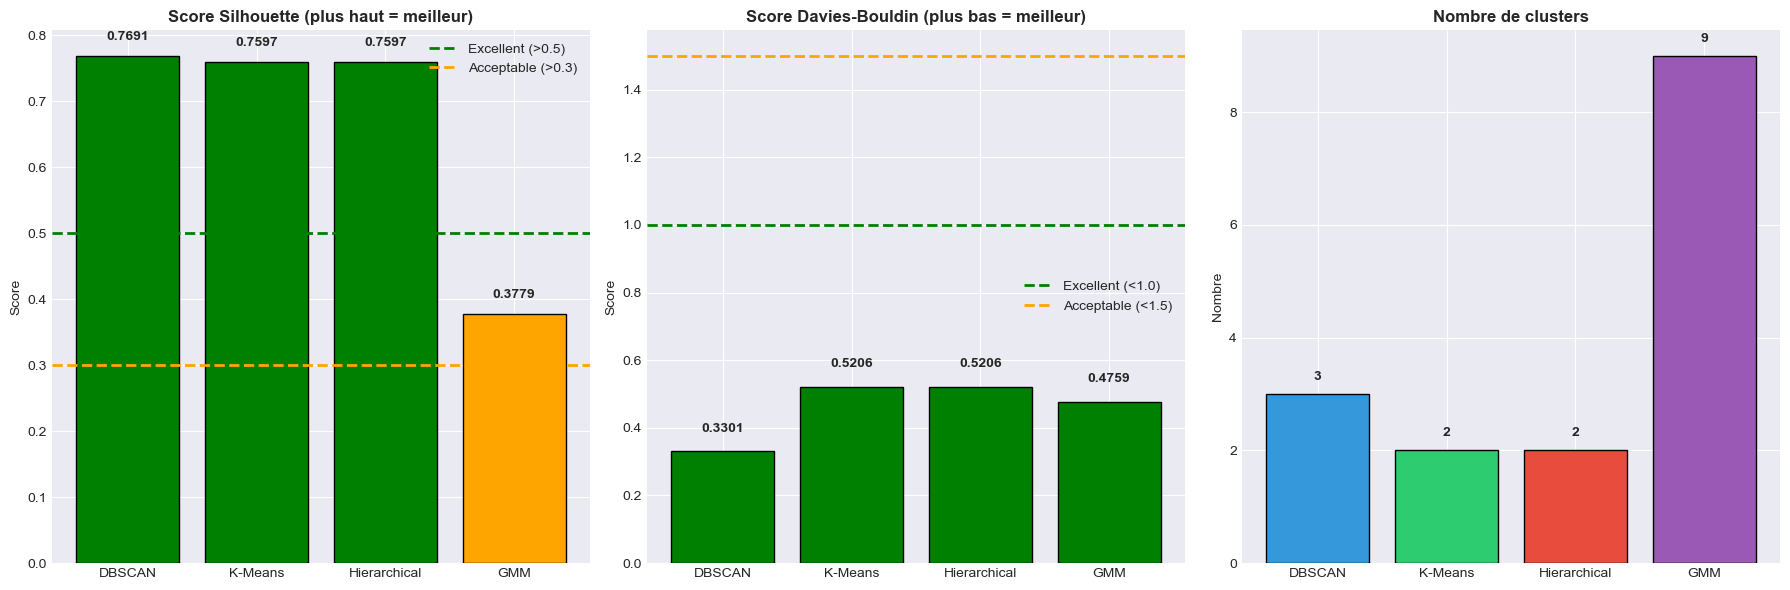

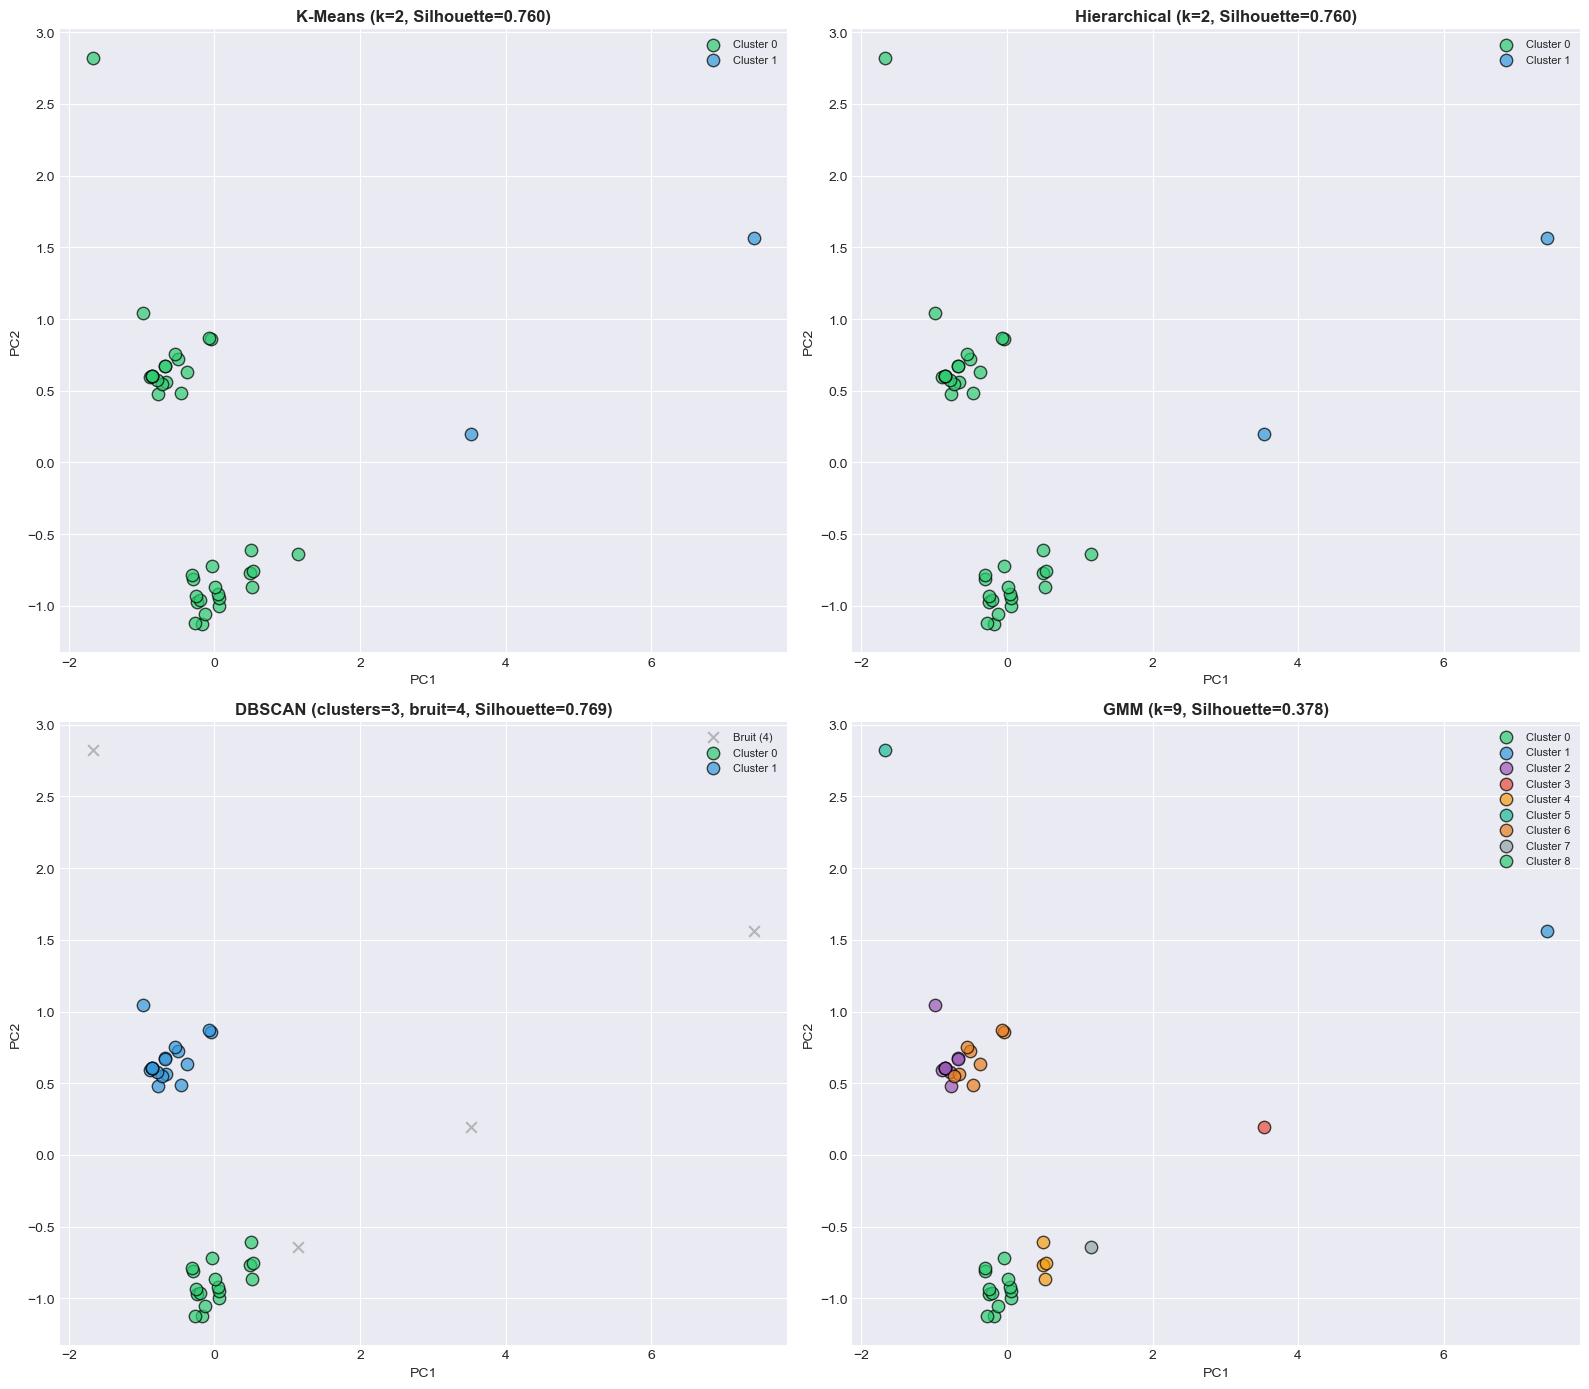


🏆 RAPPORT FINAL - COMPARAISON DES MODÈLES

┌─────────────────────────────────────────────────────────────────────────────────────┐
│                         COMPARAISON DES 4 MODÈLES                                    │
├─────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                      │
│   📊 CLASSEMENT (par Score Silhouette) :                                            │
│                                                                                      │
│   1. DBSCAN : Silhouette = 0.7691                               │
│   2. K-Means : Silhouette = 0.7597                               │
│   3. Hierarchical : Silhouette = 0.7597                               │
│                                                                                      │
│   🏆 MEILLEUR MODÈLE : DBSCAN                                                 │
│   ├── Score Silhouette : 0.7691            

In [17]:
# CELLULE 2.6 : COMPARAISON DES 4 MODÈLES DE CLUSTERING (CORRIGÉE)

print("\n" + "="*70)
print("📊 COMPARAISON DES 4 MODÈLES DE CLUSTERING")
print("K-Means vs Hierarchical vs DBSCAN vs GMM")
print("="*70)

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================================
# 1. PRÉPARATION DES DONNÉES
# ============================================

if 'X_scaled' not in locals():
    from sklearn.preprocessing import StandardScaler
    features = ['recency', 'frequency', 'monetary']
    X = rfm[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

# PCA pour visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
rfm['pca_1'] = X_pca[:, 0]
rfm['pca_2'] = X_pca[:, 1]

print(f"✅ Variance expliquée par PC1 : {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"✅ Variance expliquée par PC2 : {pca.explained_variance_ratio_[1]*100:.2f}%")

# ============================================
# 2. CRÉATION DES MODÈLES MANQUANTS
# ============================================

# Hierarchical Clustering (si pas déjà fait)
if 'segment_hier' not in rfm.columns:
    print("\n🔧 Création du modèle Hierarchical...")
    from sklearn.cluster import AgglomerativeClustering
    
    # Utiliser le même nombre de clusters que K-Means
    best_k_hier = optimal_k
    hier = AgglomerativeClustering(n_clusters=best_k_hier, linkage='ward')
    rfm['segment_hier'] = hier.fit_predict(X_scaled)
    silhouette_hier = silhouette_score(X_scaled, rfm['segment_hier'])
    print(f"✅ Hierarchical créé: k={best_k_hier}, Silhouette={silhouette_hier:.4f}")
else:
    best_k_hier = len(rfm['segment_hier'].unique())
    silhouette_hier = silhouette_score(X_scaled, rfm['segment_hier'])

# DBSCAN (si pas déjà fait)
if 'segment_dbscan' not in rfm.columns:
    print("\n🔧 Création du modèle DBSCAN...")
    from sklearn.cluster import DBSCAN
    
    best_eps = 0.8
    dbscan = DBSCAN(eps=best_eps, min_samples=3)
    rfm['segment_dbscan'] = dbscan.fit_predict(X_scaled)
    n_clusters_db = len(set(rfm['segment_dbscan'])) - (1 if -1 in rfm['segment_dbscan'] else 0)
    n_noise_db = (rfm['segment_dbscan'] == -1).sum()
    
    if n_clusters_db >= 2:
        mask = rfm['segment_dbscan'] != -1
        best_silhouette_db = silhouette_score(X_scaled[mask], rfm.loc[mask, 'segment_dbscan'])
    else:
        best_silhouette_db = 0
    print(f"✅ DBSCAN créé: clusters={n_clusters_db}, bruit={n_noise_db}, Silhouette={best_silhouette_db:.4f}")
else:
    n_clusters_db = len(set(rfm['segment_dbscan'])) - (1 if -1 in rfm['segment_dbscan'] else 0)
    n_noise_db = (rfm['segment_dbscan'] == -1).sum()
    if n_clusters_db >= 2:
        mask = rfm['segment_dbscan'] != -1
        best_silhouette_db = silhouette_score(X_scaled[mask], rfm.loc[mask, 'segment_dbscan'])
    else:
        best_silhouette_db = 0

# GMM (si pas déjà fait)
if 'segment_gmm' not in rfm.columns:
    print("\n🔧 Création du modèle GMM...")
    from sklearn.mixture import GaussianMixture
    
    best_k_gmm = min(optimal_k, 5)
    gmm = GaussianMixture(n_components=best_k_gmm, random_state=42)
    rfm['segment_gmm'] = gmm.fit_predict(X_scaled)
    silhouette_gmm = silhouette_score(X_scaled, rfm['segment_gmm'])
    print(f"✅ GMM créé: k={best_k_gmm}, Silhouette={silhouette_gmm:.4f}")
else:
    best_k_gmm = len(rfm['segment_gmm'].unique())
    silhouette_gmm = silhouette_score(X_scaled, rfm['segment_gmm'])

# ============================================
# 3. TABLEAU COMPARATIF DES MÉTRIQUES
# ============================================

comparison_data = []

# K-Means
comparison_data.append({
    'Modèle': 'K-Means',
    'Clusters': optimal_k,
    'Silhouette': max(silhouette_scores),
    'Davies-Bouldin': davies_bouldin_score(X_scaled, rfm['segment_kmeans']),
    'Bruit': 0,
    'Avantages': 'Rapide, facile à interpréter',
    'Inconvénients': 'Sensible aux outliers, clusters sphériques'
})

# Hierarchical
comparison_data.append({
    'Modèle': 'Hierarchical',
    'Clusters': best_k_hier,
    'Silhouette': silhouette_hier,
    'Davies-Bouldin': davies_bouldin_score(X_scaled, rfm['segment_hier']),
    'Bruit': 0,
    'Avantages': 'Dendrogramme visible, pas de k à choisir',
    'Inconvénients': 'Lent pour grandes données'
})

# DBSCAN
if n_clusters_db >= 2:
    comparison_data.append({
        'Modèle': 'DBSCAN',
        'Clusters': n_clusters_db,
        'Silhouette': best_silhouette_db,
        'Davies-Bouldin': davies_bouldin_score(X_scaled[rfm['segment_dbscan']!=-1], 
                                                rfm[rfm['segment_dbscan']!=-1]['segment_dbscan'].values),
        'Bruit': n_noise_db,
        'Avantages': 'Détecte les outliers, clusters non sphériques',
        'Inconvénients': 'Sensible aux paramètres eps'
    })

# GMM
comparison_data.append({
    'Modèle': 'GMM',
    'Clusters': best_k_gmm,
    'Silhouette': silhouette_gmm,
    'Davies-Bouldin': davies_bouldin_score(X_scaled, rfm['segment_gmm']),
    'Bruit': 0,
    'Avantages': 'Probabiliste, clusters de forme variable',
    'Inconvénients': 'Complexe, peut surapprendre'
})

comparison_df = pd.DataFrame(comparison_data).sort_values('Silhouette', ascending=False)

print("\n📊 TABLEAU COMPARATIF DES PERFORMANCES :")
print("="*90)
print(comparison_df[['Modèle', 'Clusters', 'Silhouette', 'Davies-Bouldin', 'Bruit']].to_string(index=False))
print("="*90)

# ============================================
# 4. GRAPHIQUE 1 : COMPARAISON DES MÉTRIQUES
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Silhouette
colors_sil = ['green' if s > 0.5 else 'orange' if s > 0.3 else 'red' for s in comparison_df['Silhouette']]
bars1 = axes[0].bar(comparison_df['Modèle'], comparison_df['Silhouette'], color=colors_sil, edgecolor='black')
axes[0].axhline(y=0.5, color='green', linestyle='--', linewidth=2, label='Excellent (>0.5)')
axes[0].axhline(y=0.3, color='orange', linestyle='--', linewidth=2, label='Acceptable (>0.3)')
axes[0].set_title('Score Silhouette (plus haut = meilleur)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend()
for bar, val in zip(bars1, comparison_df['Silhouette']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Davies-Bouldin
colors_db = ['green' if d < 1 else 'orange' if d < 1.5 else 'red' for d in comparison_df['Davies-Bouldin']]
bars2 = axes[1].bar(comparison_df['Modèle'], comparison_df['Davies-Bouldin'], color=colors_db, edgecolor='black')
axes[1].axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Excellent (<1.0)')
axes[1].axhline(y=1.5, color='orange', linestyle='--', linewidth=2, label='Acceptable (<1.5)')
axes[1].set_title('Score Davies-Bouldin (plus bas = meilleur)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].legend()
for bar, val in zip(bars2, comparison_df['Davies-Bouldin']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Nombre de clusters
bars3 = axes[2].bar(comparison_df['Modèle'], comparison_df['Clusters'], 
                    color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'], edgecolor='black')
axes[2].set_title('Nombre de clusters', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Nombre')
for bar, val in zip(bars3, comparison_df['Clusters']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                 str(val), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 5. GRAPHIQUE 2 : VISUALISATION COMPARÉE (PCA)
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

colors_list = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c', '#e67e22', '#95a5a6']

# K-Means
for i in range(optimal_k):
    mask = rfm['segment_kmeans'] == i
    axes[0].scatter(rfm.loc[mask, 'pca_1'], rfm.loc[mask, 'pca_2'], 
                    c=colors_list[i % len(colors_list)], label=f'Cluster {i}', 
                    s=80, alpha=0.7, edgecolors='black')
axes[0].set_title(f'K-Means (k={optimal_k}, Silhouette={max(silhouette_scores):.3f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8)

# Hierarchical
for i in range(best_k_hier):
    mask = rfm['segment_hier'] == i
    axes[1].scatter(rfm.loc[mask, 'pca_1'], rfm.loc[mask, 'pca_2'], 
                    c=colors_list[i % len(colors_list)], label=f'Cluster {i}', 
                    s=80, alpha=0.7, edgecolors='black')
axes[1].set_title(f'Hierarchical (k={best_k_hier}, Silhouette={silhouette_hier:.3f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8)

# DBSCAN
unique_labels = sorted(rfm['segment_dbscan'].unique())
for label in unique_labels:
    mask = rfm['segment_dbscan'] == label
    if label == -1:
        axes[2].scatter(rfm.loc[mask, 'pca_1'], rfm.loc[mask, 'pca_2'], 
                        c='gray', label=f'Bruit ({n_noise_db})', s=60, alpha=0.5, marker='x')
    else:
        axes[2].scatter(rfm.loc[mask, 'pca_1'], rfm.loc[mask, 'pca_2'], 
                        c=colors_list[label % len(colors_list)], label=f'Cluster {label}', 
                        s=80, alpha=0.7, edgecolors='black')
axes[2].set_title(f'DBSCAN (clusters={n_clusters_db}, bruit={n_noise_db}, Silhouette={best_silhouette_db:.3f})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend(fontsize=8)

# GMM
for i in range(best_k_gmm):
    mask = rfm['segment_gmm'] == i
    axes[3].scatter(rfm.loc[mask, 'pca_1'], rfm.loc[mask, 'pca_2'], 
                    c=colors_list[i % len(colors_list)], label=f'Cluster {i}', 
                    s=80, alpha=0.7, edgecolors='black')
axes[3].set_title(f'GMM (k={best_k_gmm}, Silhouette={silhouette_gmm:.3f})', fontsize=12, fontweight='bold')
axes[3].set_xlabel('PC1')
axes[3].set_ylabel('PC2')
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============================================
# 6. RAPPORT FINAL
# ============================================

best_model = comparison_df.iloc[0]['Modèle']
best_silhouette = comparison_df.iloc[0]['Silhouette']

print("\n" + "="*70)
print("🏆 RAPPORT FINAL - COMPARAISON DES MODÈLES")
print("="*70)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────────────┐
│                         COMPARAISON DES 4 MODÈLES                                    │
├─────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                      │
│   📊 CLASSEMENT (par Score Silhouette) :                                            │
│                                                                                      │
│   1. {comparison_df.iloc[0]['Modèle']} : Silhouette = {comparison_df.iloc[0]['Silhouette']:.4f}                               │
│   2. {comparison_df.iloc[1]['Modèle']} : Silhouette = {comparison_df.iloc[1]['Silhouette']:.4f}                               │
│   3. {comparison_df.iloc[2]['Modèle']} : Silhouette = {comparison_df.iloc[2]['Silhouette']:.4f}                               │
│                                                                                      │
│   🏆 MEILLEUR MODÈLE : {best_model}                                                 │
│   ├── Score Silhouette : {best_silhouette:.4f}                                      │
│   └── Davies-Bouldin : {comparison_df.iloc[0]['Davies-Bouldin']:.4f}                │
│                                                                                      │
│   💡 RECOMMANDATION FINALE :                                                         │
│   ✅ Utiliser {best_model} pour la segmentation client                              │
│   ✅ Utiliser DBSCAN pour détecter les clients atypiques                             │
│                                                                                      │
└─────────────────────────────────────────────────────────────────────────────────────┘
""")

print("="*70)
print("✅ Comparaison des 4 modèles terminée")
print("="*70)

In [20]:
# CELLULE 5.2 : Deep Learning - LSTM pour prédiction des ventes

print("\n" + "="*70)
print("🚀 OBJECTIF 5 : LSTM - PRÉDICTION DES VENTES")
print("="*70)

try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    from sklearn.preprocessing import MinMaxScaler
    
    # Préparation des données pour LSTM
    scaler_lstm = MinMaxScaler()
    data_scaled = scaler_lstm.fit_transform(df_weekly[['quantity']].values)
    
    # Création des séquences
    def create_sequences(data, seq_length=10):
        X, y = [], []
        for i in range(len(data) - seq_length):
            X.append(data[i:i+seq_length])
            y.append(data[i+seq_length])
        return np.array(X), np.array(y)
    
    seq_length = 5
    X_lstm, y_lstm = create_sequences(data_scaled, seq_length)
    
    # Split
    split = int(len(X_lstm) * 0.8)
    X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
    y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]
    
    # Modèle LSTM
    model_lstm = Sequential([
        LSTM(50, activation='relu', return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(0.2),
        LSTM(50, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    
    model_lstm.compile(optimizer='adam', loss='mse')
    print(model_lstm.summary())
    
    # Entraînement
    early_stop = EarlyStopping(patience=10, restore_best_weights=True)
    history = model_lstm.fit(X_train_lstm, y_train_lstm, 
                              epochs=50, batch_size=8, 
                              validation_split=0.1, 
                              callbacks=[early_stop], 
                              verbose=0)
    
    # Prédictions
    y_pred_lstm = model_lstm.predict(X_test_lstm)
    y_pred_lstm = scaler_lstm.inverse_transform(y_pred_lstm)
    y_test_lstm_orig = scaler_lstm.inverse_transform(y_test_lstm)
    
    mae_lstm = mean_absolute_error(y_test_lstm_orig, y_pred_lstm)
    print(f"MAE LSTM: {mae_lstm:.2f} unités")
    
    # Graphique
    plt.figure(figsize=(14, 5))
    plt.plot(y_test_lstm_orig, label='Réel', color='blue')
    plt.plot(y_pred_lstm, label='Prédiction LSTM', color='red', linestyle='--')
    plt.title('Prédiction des ventes avec LSTM')
    plt.xlabel('Jours')
    plt.ylabel('Quantité')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("❌ TensorFlow non installé. Installation: pip install tensorflow")


🚀 OBJECTIF 5 : LSTM - PRÉDICTION DES VENTES
❌ TensorFlow non installé. Installation: pip install tensorflow
